In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from itertools import combinations
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor, StackingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

In [123]:
df = pd.read_csv("stock_8_train.csv")
test_df = pd.read_csv("stock_8_test.csv")

In [97]:
df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
0,-0.045586,1.895412,-0.926036,0.891318,1.048293,0.721750,1.996457,0.955207,1.804655,-0.727166,...,0.660774,0.416208,-1.832328,2.339303,0.804269,-0.977420,0.722452,2.308842,1.864337,151.136995
1,-1.135796,0.204168,0.699510,-1.782274,0.684938,-1.674062,-0.117594,-1.163391,1.431247,0.101419,...,-0.849963,-1.574958,0.592602,-0.557672,-1.616292,0.209309,-1.723437,0.423761,-0.117409,212.640490
2,1.653209,-1.089071,0.790120,-1.076474,-1.270608,-1.211591,0.605014,0.129893,-0.314689,0.690523,...,0.372702,-1.276008,0.883874,-1.243772,-0.976039,0.877692,-1.777056,-1.398819,0.575572,190.339209
3,-1.034075,0.201769,0.219310,-0.230437,-0.166689,-0.353950,1.872708,-0.416184,0.340937,0.327131,...,-0.341503,-0.389296,-0.150212,0.537197,0.253607,0.664897,-0.135531,0.232780,1.740391,200.195814
4,0.341025,-0.267755,0.903310,0.143910,-1.147876,-2.423280,1.826059,-0.222850,-0.612929,1.194194,...,0.046391,-2.309458,0.509615,-0.478709,0.342498,0.957646,-2.946391,-0.714417,1.853803,163.641599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,-0.821262,-1.140998,-0.343863,0.522432,0.749880,1.809411,-0.022624,0.154359,-0.024881,-0.254248,...,-0.206465,1.528439,0.357017,-0.738320,0.214560,-0.123842,1.725726,-1.079713,-0.140339,194.091701
1995,2.040828,-0.697405,-2.106428,0.342128,-0.707969,0.243847,-0.089535,0.549876,-0.099623,-1.820533,...,0.606765,-0.010956,-2.345193,-0.592569,1.135094,-1.875510,0.624114,-0.466048,0.169794,210.107511
1996,0.334122,2.776120,-0.247423,1.098028,-0.392997,0.902848,-0.248387,0.461368,2.390136,-0.334704,...,0.330230,0.819965,-0.109245,2.886089,1.540925,-0.205645,0.926763,3.103376,0.063373,189.865402
1997,-0.584432,0.840201,0.491467,0.645508,0.896749,1.993323,-0.848997,0.845999,0.398119,0.744653,...,0.362254,2.015359,0.717188,0.787582,1.067042,0.240455,2.326161,1.006195,-1.050165,195.172889


In [98]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,...,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,-0.028565,0.019965,0.008021,-0.005876,0.011867,0.002223,0.015683,-0.005041,0.001797,0.009604,...,-0.012649,0.019263,0.003991,0.013322,-0.019211,0.017984,0.001021,0.006160,0.018643,197.352647
std,0.976517,1.001753,0.984983,0.992547,1.333273,1.018394,0.981255,1.004485,1.020447,1.040564,...,1.071351,1.082457,1.063250,1.057348,1.053369,1.048605,1.077244,1.071601,1.040648,26.313732
min,-3.103096,-3.453305,-4.389115,-3.236735,-7.969237,-3.887804,-3.119475,-3.792258,-3.464363,-4.531672,...,-3.540063,-4.295863,-4.351873,-3.272701,-3.341770,-5.177935,-3.893999,-3.776715,-3.249119,80.000000
25%,-0.642040,-0.671780,-0.664647,-0.656047,-0.685387,-0.672146,-0.621649,-0.697386,-0.691439,-0.688977,...,-0.731951,-0.673408,-0.705520,-0.711827,-0.719373,-0.695495,-0.726171,-0.705333,-0.676659,186.789195
50%,-0.035284,0.003934,-0.009141,-0.006412,-0.018561,-0.019916,0.011930,0.008137,-0.032627,-0.003857,...,0.018191,0.008551,-0.020134,-0.027309,-0.037648,0.009446,-0.022081,0.009483,0.029038,195.785795
75%,0.611702,0.706789,0.635515,0.645116,0.670959,0.679595,0.654489,0.695180,0.686198,0.698279,...,0.701750,0.732248,0.717489,0.739905,0.704396,0.711148,0.699648,0.723007,0.705610,205.905735
max,3.157756,3.348603,3.225993,3.080606,7.941240,3.682510,4.087923,3.098282,3.867607,3.787275,...,3.505973,3.825703,3.560937,3.698926,3.287155,3.879560,3.693713,3.802593,4.249843,400.000000


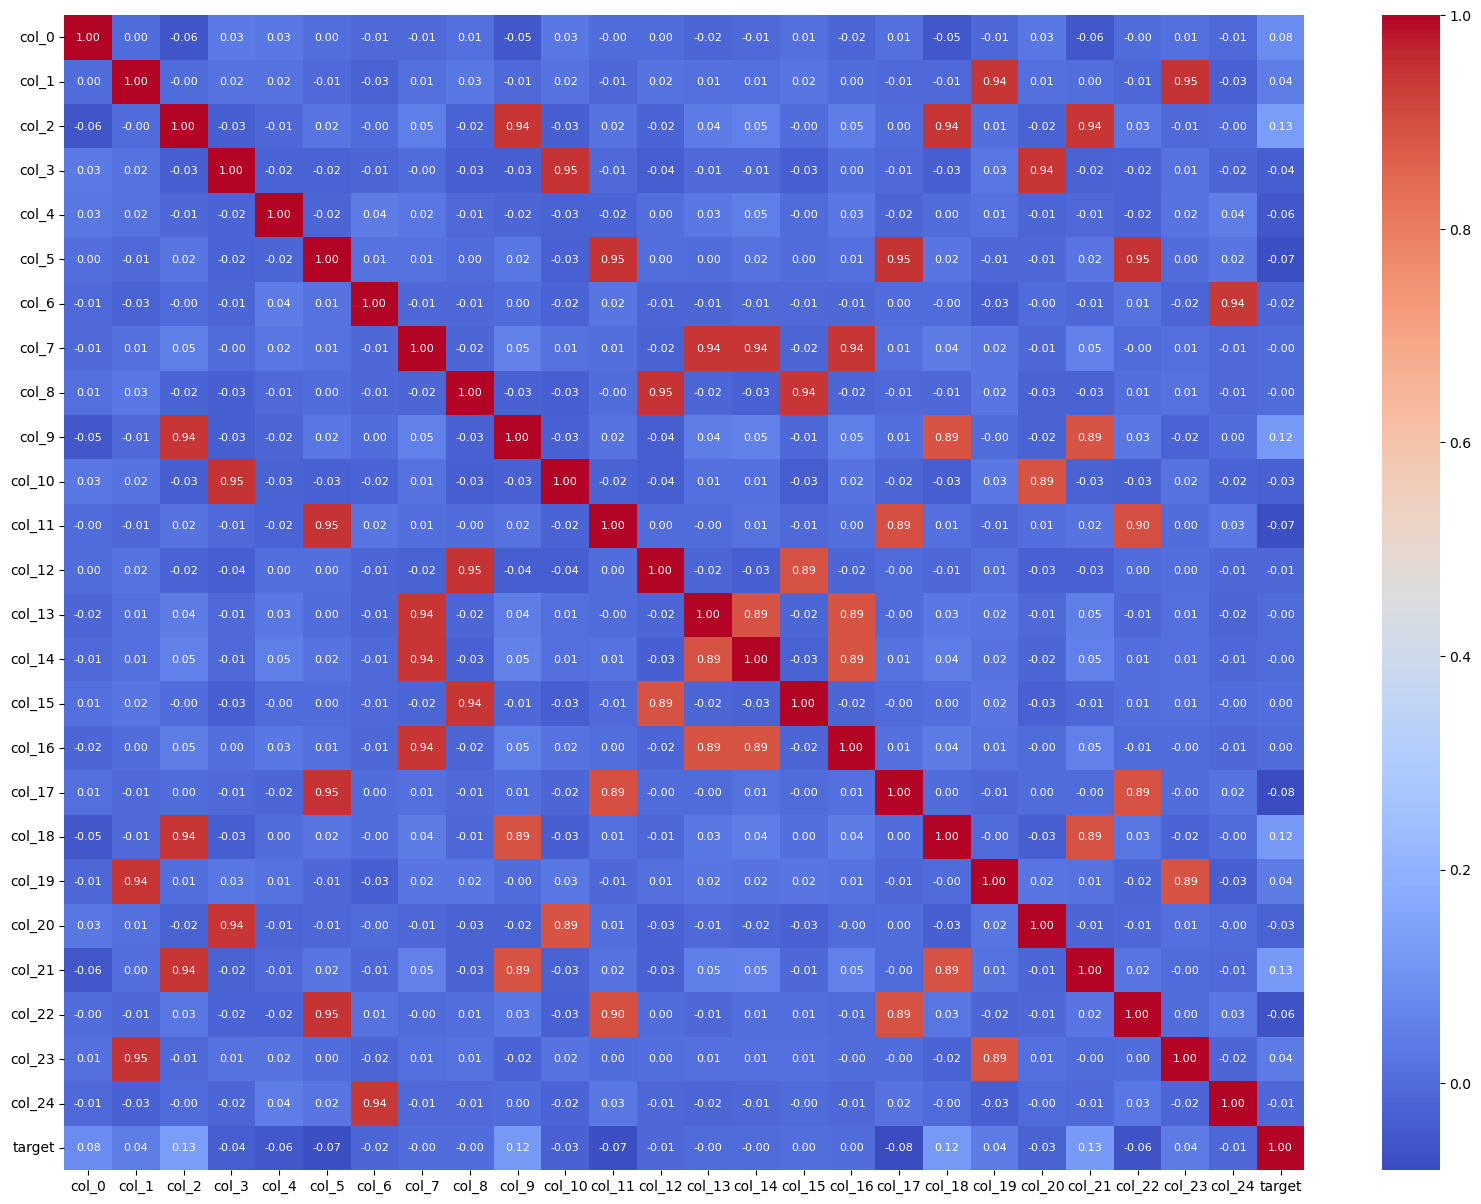

In [99]:
# Make the figure much larger (e.g., 20 inches by 15 inches)
plt.figure(figsize=(20, 15))

# Plot with 'annot=True' but a smaller font size
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.show()

some features are veyr highly correlated and therefore need to be dropped.

C:\Users\kiera\AppData\Local\Temp\ipykernel_14640\1896116364.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


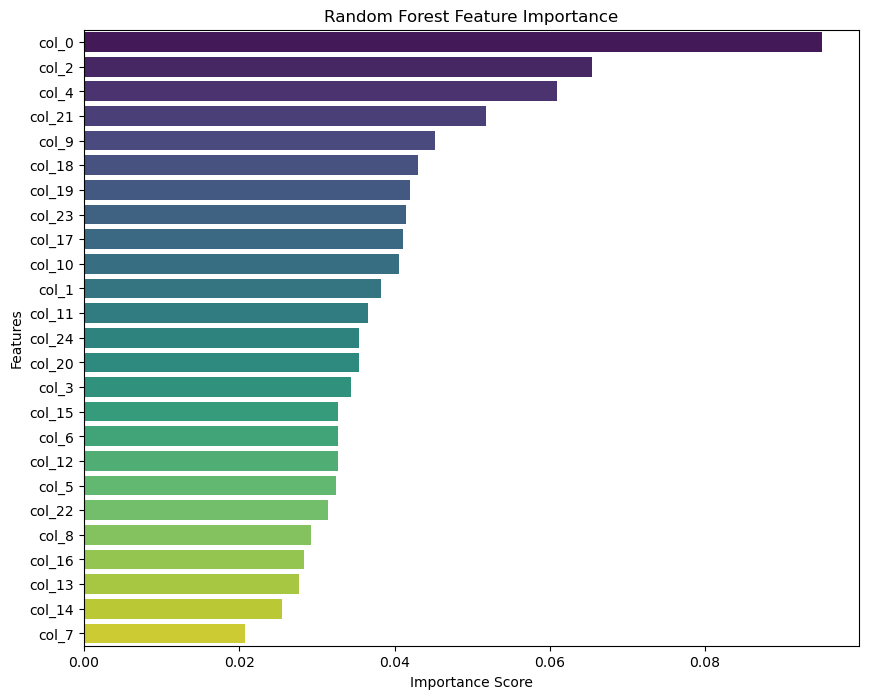

   feature  importance
0    col_0    0.095082
2    col_2    0.065457
4    col_4    0.060980
21  col_21    0.051719
9    col_9    0.045155
18  col_18    0.043002
19  col_19    0.041947
23  col_23    0.041440
17  col_17    0.041128
10  col_10    0.040553
1    col_1    0.038254
11  col_11    0.036600
24  col_24    0.035396
20  col_20    0.035381
3    col_3    0.034453
15  col_15    0.032770
6    col_6    0.032728
12  col_12    0.032673
5    col_5    0.032474
22  col_22    0.031383
8    col_8    0.029225
16  col_16    0.028284
13  col_13    0.027673
14  col_14    0.025551
7    col_7    0.020692


In [100]:
X = df.drop(columns=['target'])
y = df['target']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

print(feature_importance)

In [101]:
estimator = RandomForestRegressor(n_estimators=50, random_state=42)

# recursive feature elimination
selector = RFECV(estimator, step=1, cv=5, scoring='neg_mean_squared_error')
selector = selector.fit(X, y)

print(f"Optimal number of features: {selector.n_features_}")

keep_columns = X.columns[selector.support_]
print(f"Features to keep: {list(keep_columns)}")

Optimal number of features: 21
Features to keep: ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_23', 'col_24']


In [102]:
def feature_analysis(col, n_bins=4):
    df[f'{col}_cut'] = pd.qcut(df[col], n_bins)
    display(df.groupby([f"{col}_cut"], as_index=False, observed=True)['target'].mean())

    temp_df = df.groupby(f"{col}_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

    temp_df['noise_ratio'] = temp_df['std'] / temp_df['mean']
    display(temp_df)

    plt.figure(figsize=(12, 6))    
    ax = sns.barplot(
        data=df, 
        x=f'{col}_cut', 
        y='target', 
        palette='RdBu_r', 
        hue=f'{col}_cut',
        legend=False,
        errorbar=('ci', 95)
    )
    
    global_mean = df['target'].mean()
    plt.axhline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Avg ({global_mean:.3f})')
    
    plt.title(f'Target Distribution by {col} Quantiles ({n_bins} Bins)', fontsize=14)
    plt.xlabel(f'{col} Quantile Ranges')
    plt.ylabel('Mean Target')
    plt.xticks(rotation=30)
    plt.legend()
    plt.show()

# eda

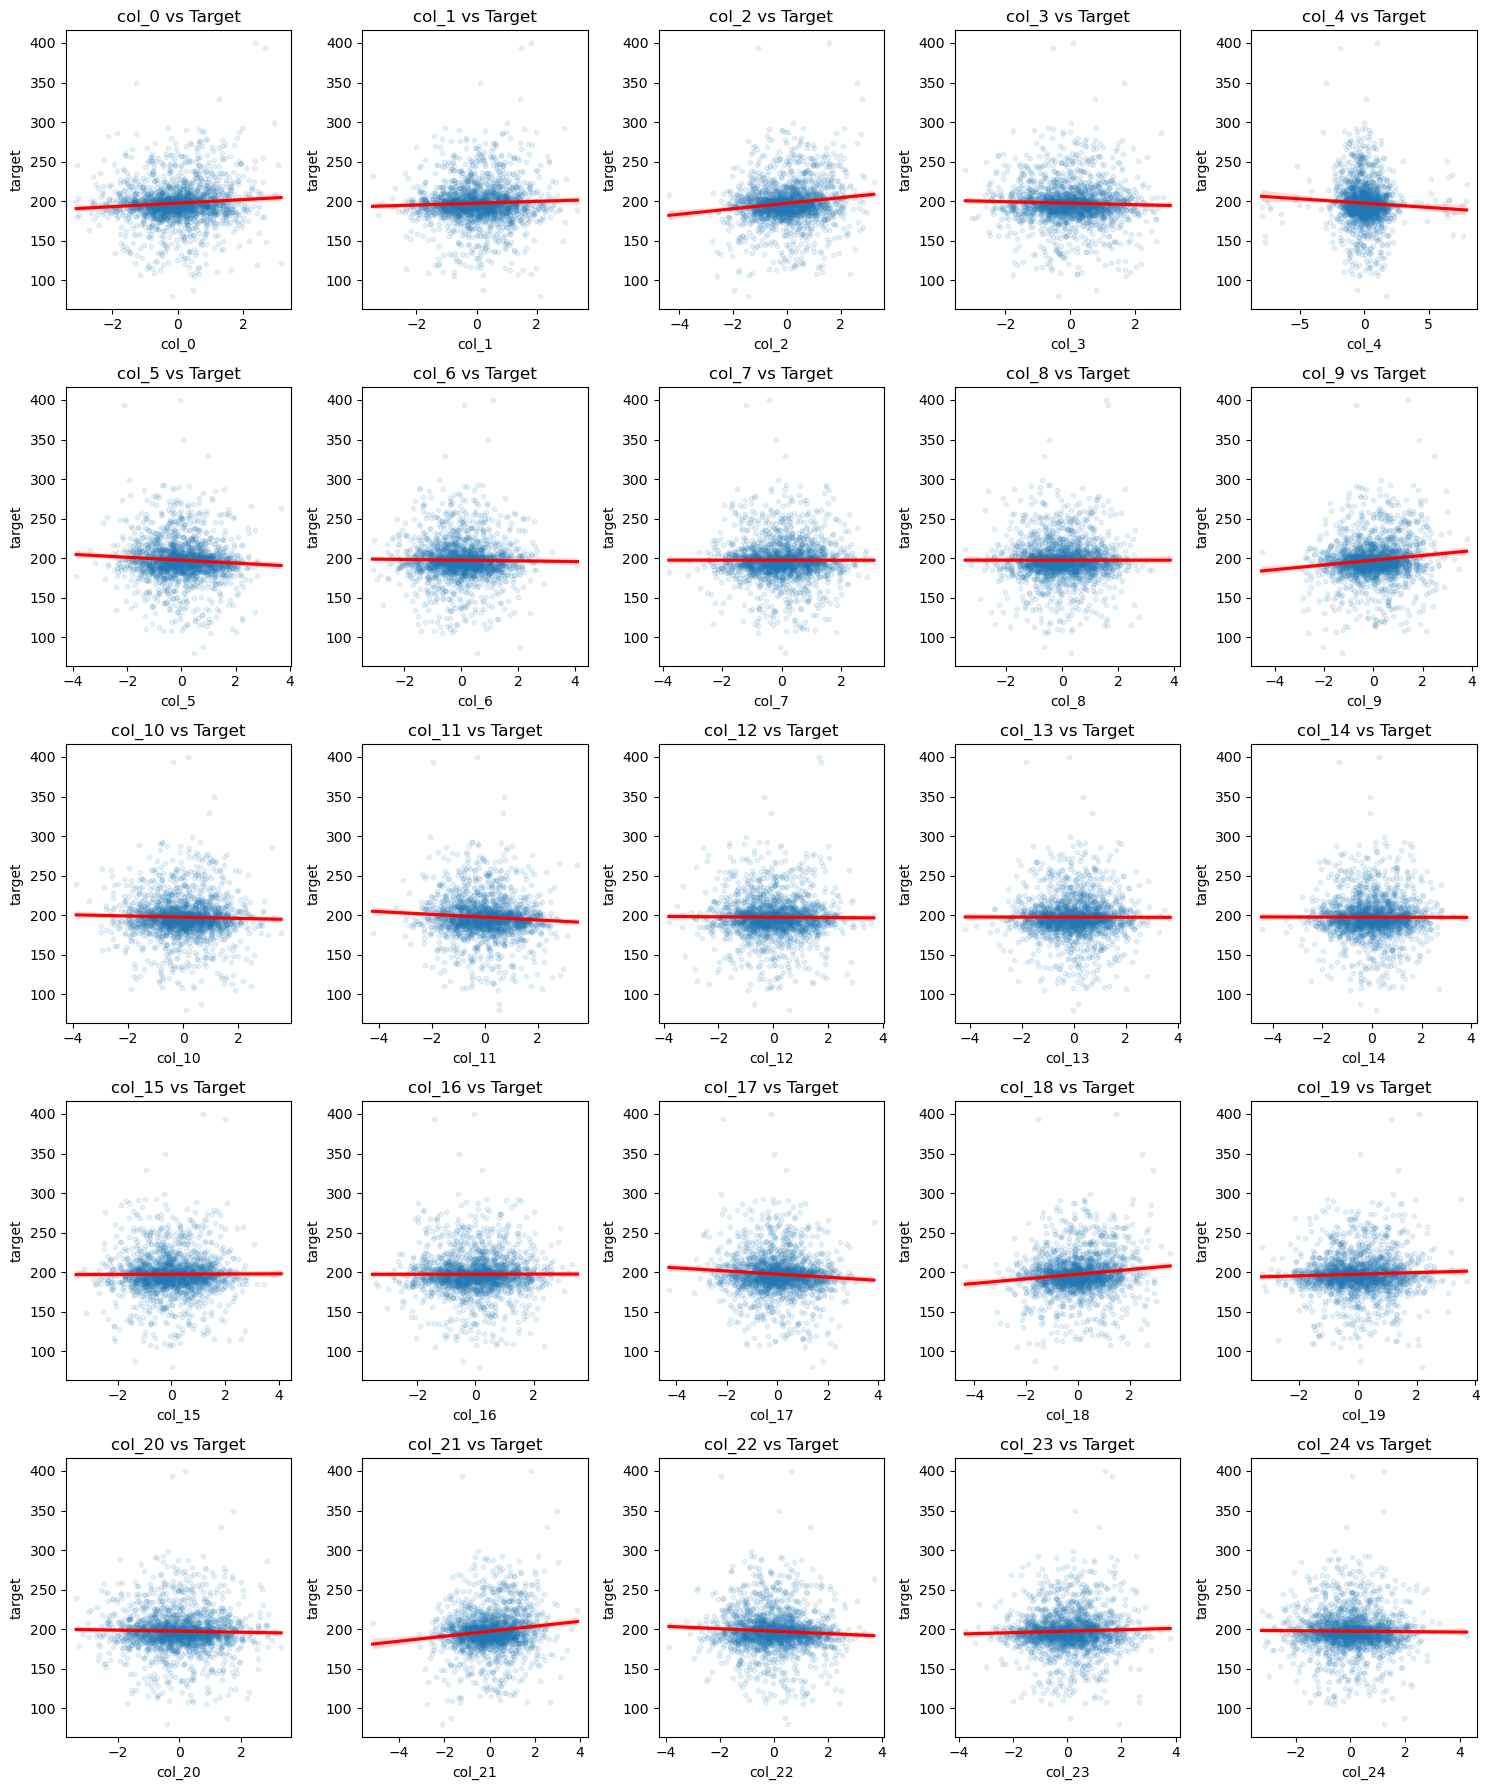

In [104]:
features = [col for col in df.columns if col.startswith('col_')]

fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.regplot(x=df[col], y=df['target'], ax=axes[i], 
                scatter_kws={'alpha':0.1, 's':10},
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

## col_0

,col_0_cut,target
0,"(-3.104, -0.911]",197.032004
1,"(-0.911, -0.44]",193.590917
2,"(-0.44, -0.0353]",196.367830
3,"(-0.0353, 0.366]",196.273385
4,"(0.366, 0.899]",197.513432
5,"(0.899, 3.158]",203.309808


,mean,median,std,count,min,max,noise_ratio
col_0_cut,,,,,,,
"(-3.104, -0.911]",197.032004,196.432153,25.741026,334,106.201614,349.973208,0.130644
"(-0.911, -0.44]",193.590917,193.711384,22.904177,332,108.665528,273.747141,0.118312
"(-0.44, -0.0353]",196.367830,195.422061,22.873927,334,80.000000,292.416417,0.116485
"(-0.0353, 0.366]",196.273385,196.265767,22.183635,332,116.253370,290.140708,0.113024
"(0.366, 0.899]",197.513432,196.539244,29.534727,333,87.691504,291.436374,0.149533
"(0.899, 3.158]",203.309808,197.719318,32.193218,334,110.494596,400.000000,0.158346


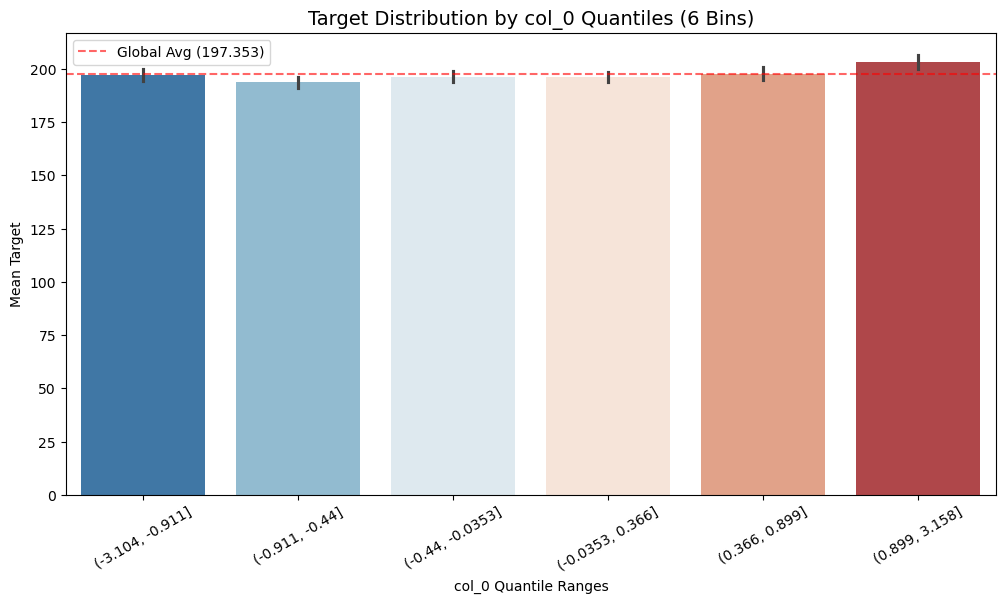

In [105]:
feature_analysis("col_0", 6)

In [86]:
df['col_0_high'] = (df['col_0'] > 0.612).astype(int)

,col_1_cut,target
0,"(-3.4539999999999997, -1.226]",194.049803
1,"(-1.226, -0.812]",198.346540
2,"(-0.812, -0.516]",196.263501
3,"(-0.516, -0.238]",197.224320
4,"(-0.238, 0.00393]",198.569654
5,"(0.00393, 0.271]",195.356509
6,"(0.271, 0.556]",196.493907
7,"(0.556, 0.883]",200.977254
8,"(0.883, 1.294]",194.811952
9,"(1.294, 3.349]",201.423049


,mean,median,std,count,min,max,noise_ratio
col_1_cut,,,,,,,
"(-3.4539999999999997, -1.226]",194.049803,194.461765,23.132515,200,108.665528,281.946756,0.119209
"(-1.226, -0.812]",198.346540,195.918676,21.474259,200,110.494596,292.860631,0.108266
"(-0.812, -0.516]",196.263501,195.818181,25.672599,200,105.263432,290.140708,0.130807
"(-0.516, -0.238]",197.224320,195.071139,21.469602,200,119.238166,280.140598,0.108859
"(-0.238, 0.00393]",198.569654,196.994836,24.123279,200,116.253370,277.314646,0.121485
"(0.00393, 0.271]",195.356509,194.034294,31.178827,199,87.691504,349.973208,0.159600
"(0.271, 0.556]",196.493907,194.623080,22.485531,200,122.386242,273.282951,0.114434
"(0.556, 0.883]",200.977254,197.309160,26.016010,200,135.682789,286.592472,0.129448
"(0.883, 1.294]",194.811952,196.088262,26.573701,200,112.641142,298.702722,0.136407


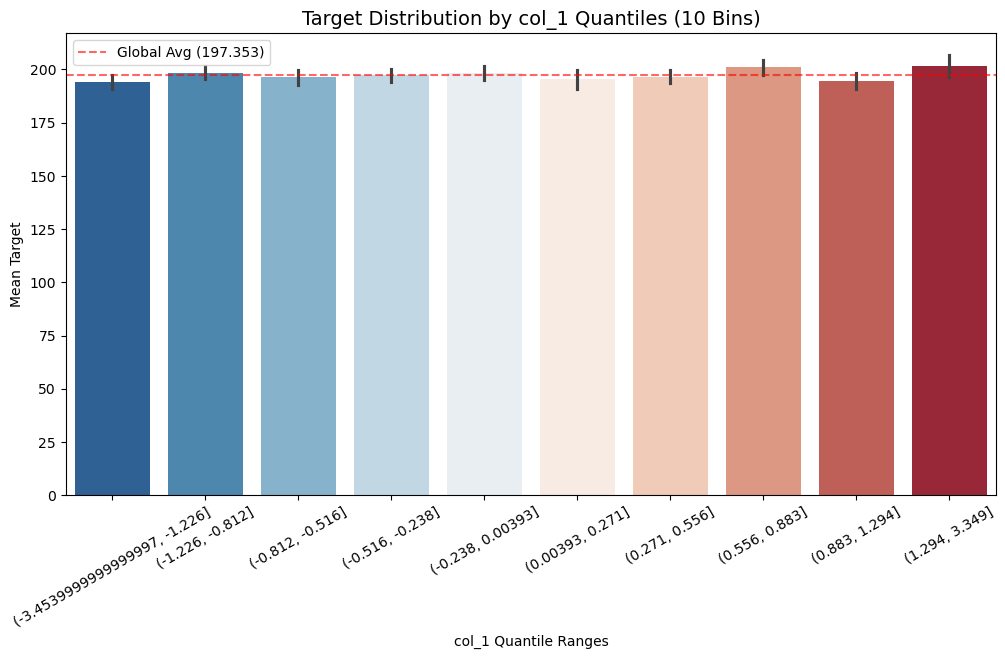

In [87]:
feature_analysis("col_1", 10)

In [88]:
df['col_1_low'] = (df['col_1'] < -1.226).astype(int)

,col_2_cut,target
0,"(-4.390000000000001, -1.223]",190.471141
1,"(-1.223, -0.804]",197.025131
2,"(-0.804, -0.511]",196.748429
3,"(-0.511, -0.238]",196.137357
4,"(-0.238, -0.00914]",194.979947
5,"(-0.00914, 0.23]",196.973569
6,"(0.23, 0.506]",198.760428
7,"(0.506, 0.82]",197.479511
8,"(0.82, 1.285]",199.393797
9,"(1.285, 3.226]",205.555265


,mean,median,std,count,min,max,noise_ratio
col_2_cut,,,,,,,
"(-4.390000000000001, -1.223]",190.471141,193.856939,29.180138,200,80.000000,276.022298,0.153200
"(-1.223, -0.804]",197.025131,194.337067,25.158943,200,133.615174,394.192258,0.127694
"(-0.804, -0.511]",196.748429,195.934892,21.493036,200,114.085108,291.436374,0.109241
"(-0.511, -0.238]",196.137357,193.490062,19.044568,200,112.641142,263.386549,0.097098
"(-0.238, -0.00914]",194.979947,193.745157,23.457477,200,115.777105,290.140708,0.120307
"(-0.00914, 0.23]",196.973569,195.936816,24.670838,199,114.736771,298.702722,0.125249
"(0.23, 0.506]",198.760428,197.480559,25.478740,200,116.253370,280.140598,0.128188
"(0.506, 0.82]",197.479511,196.131128,25.736612,200,120.154795,292.860631,0.130325
"(0.82, 1.285]",199.393797,197.449225,25.353598,200,108.366523,271.524131,0.127153


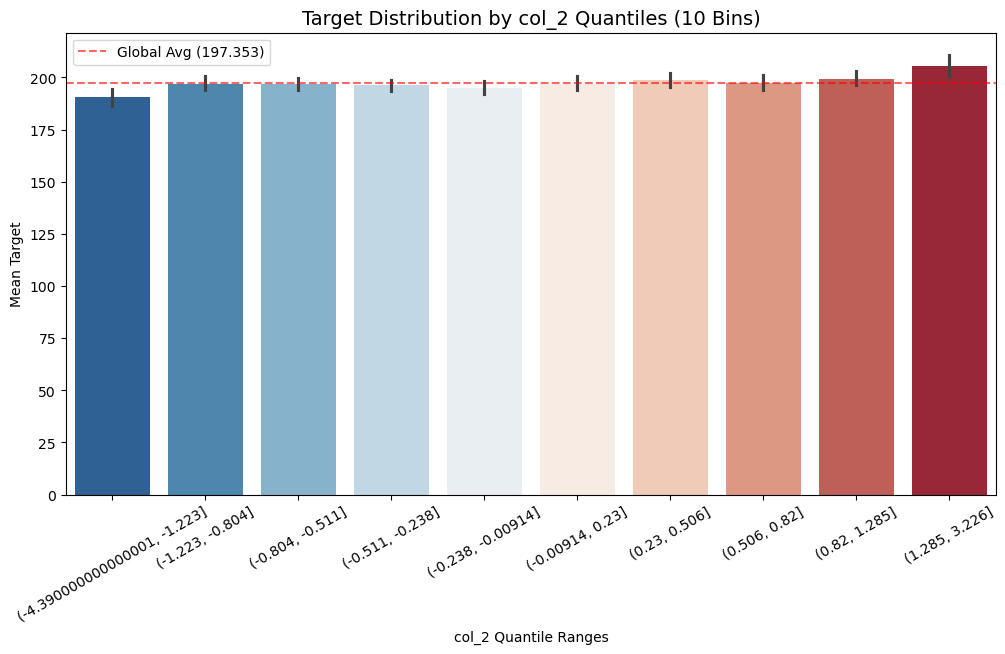

In [89]:
feature_analysis("col_2", 10)

In [90]:
df['col_2_high'] = (df['col_2'] > 1.285).astype(int)
df['col_2_low'] = (df['col_1'] < -1.223).astype(int)

,col_3_cut,target
0,"(-3.238, -1.294]",199.400540
1,"(-1.294, -0.817]",199.177121
2,"(-0.817, -0.513]",197.109013
3,"(-0.513, -0.245]",193.434586
4,"(-0.245, -0.00641]",197.435208
5,"(-0.00641, 0.252]",200.197780
6,"(0.252, 0.523]",198.617715
7,"(0.523, 0.811]",196.918785
8,"(0.811, 1.27]",196.085442
9,"(1.27, 3.081]",195.164508


,mean,median,std,count,min,max,noise_ratio
col_3_cut,,,,,,,
"(-3.238, -1.294]",199.400540,198.006724,25.894639,200,106.201614,288.510777,0.129862
"(-1.294, -0.817]",199.177121,196.848922,24.302975,200,114.736771,290.140708,0.122017
"(-0.817, -0.513]",197.109013,196.222032,29.262201,200,112.641142,394.192258,0.148457
"(-0.513, -0.245]",193.434586,195.017390,25.222977,200,80.000000,269.258083,0.130395
"(-0.245, -0.00641]",197.435208,195.576121,23.962722,200,120.659337,287.042407,0.121370
"(-0.00641, 0.252]",200.197780,196.508226,29.313802,199,107.483877,400.000000,0.146424
"(0.252, 0.523]",198.617715,195.905579,23.944403,200,110.494596,278.155918,0.120555
"(0.523, 0.811]",196.918785,194.431957,25.679934,200,87.691504,328.614535,0.130409
"(0.811, 1.27]",196.085442,195.128681,22.879398,200,119.238166,271.816445,0.116681


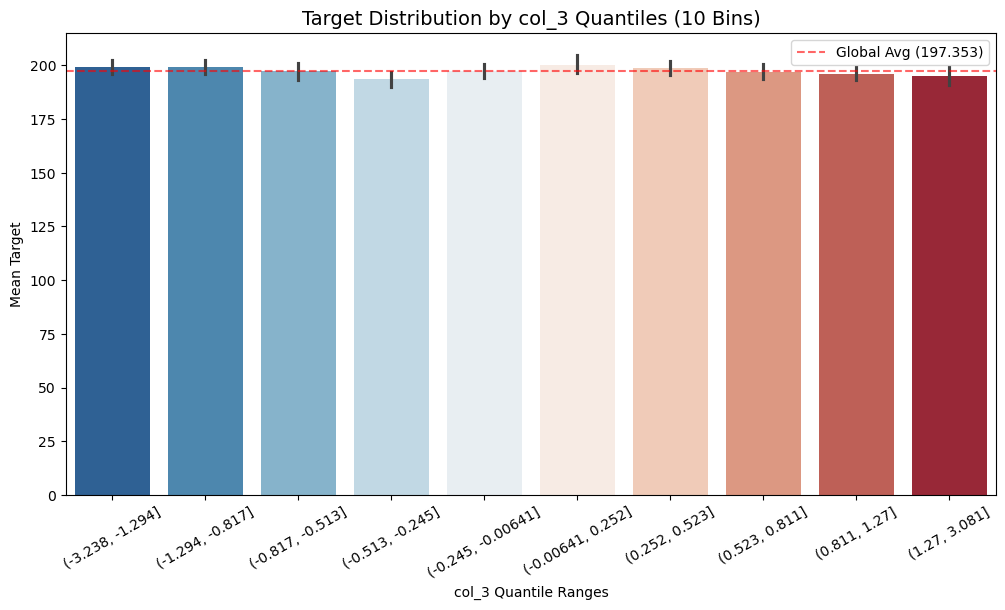

In [91]:
feature_analysis("col_3", 10)

In [92]:
# flat median across groups in col_3

,col_4_cut,target
0,"(-7.970000000000001, -0.977]",200.589380
1,"(-0.977, -0.441]",198.624219
2,"(-0.441, -0.0186]",199.411083
3,"(-0.0186, 0.407]",196.926643
4,"(0.407, 1.003]",194.988910
5,"(1.003, 7.941]",193.579516


,mean,median,std,count,min,max,noise_ratio
col_4_cut,,,,,,,
"(-7.970000000000001, -0.977]",200.589380,197.921788,30.775635,333,110.494596,394.192258,0.153426
"(-0.977, -0.441]",198.624219,196.547155,25.382293,333,87.691504,292.416417,0.127791
"(-0.441, -0.0186]",199.411083,196.957668,26.364025,334,105.263432,298.702722,0.132209
"(-0.0186, 0.407]",196.926643,195.275959,23.969415,332,112.734726,328.614535,0.121717
"(0.407, 1.003]",194.988910,194.087652,26.584534,333,108.665528,400.000000,0.136339
"(1.003, 7.941]",193.579516,194.293414,23.679180,334,80.000000,277.500687,0.122323


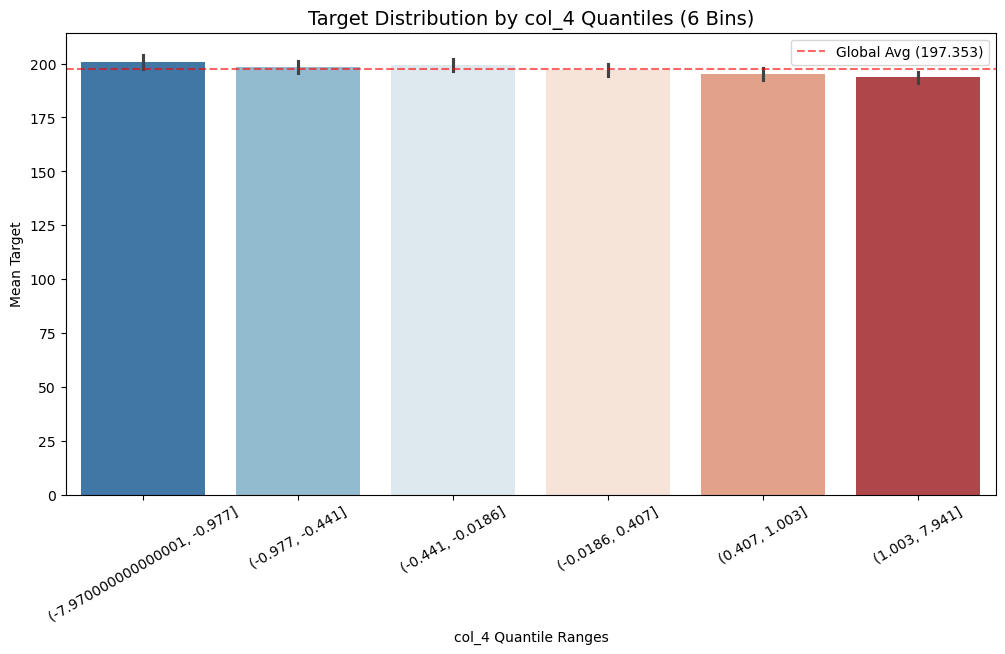

In [93]:
feature_analysis("col_4", 6)

In [74]:
df['col_4_high'] = (df['col_4'] > 1.003).astype(int)

,col_5_cut,target
0,"(-3.889, -0.978]",199.596753
1,"(-0.978, -0.416]",196.502917
2,"(-0.416, -0.0199]",200.640395
3,"(-0.0199, 0.429]",197.569440
4,"(0.429, 1.02]",196.674151
5,"(1.02, 3.683]",193.132988


,mean,median,std,count,min,max,noise_ratio
col_5_cut,,,,,,,
"(-3.889, -0.978]",199.596753,197.194726,27.903594,333,110.494596,394.192258,0.139800
"(-0.978, -0.416]",196.502917,195.594370,24.459128,333,108.366523,292.860631,0.124472
"(-0.416, -0.0199]",200.640395,197.674159,28.286563,334,107.483877,400.000000,0.140981
"(-0.0199, 0.429]",197.569440,195.595161,25.279838,333,108.665528,349.973208,0.127954
"(0.429, 1.02]",196.674151,196.529449,25.844812,332,80.000000,328.614535,0.131409
"(1.02, 3.683]",193.132988,192.929924,25.407914,334,105.263432,287.042407,0.131557


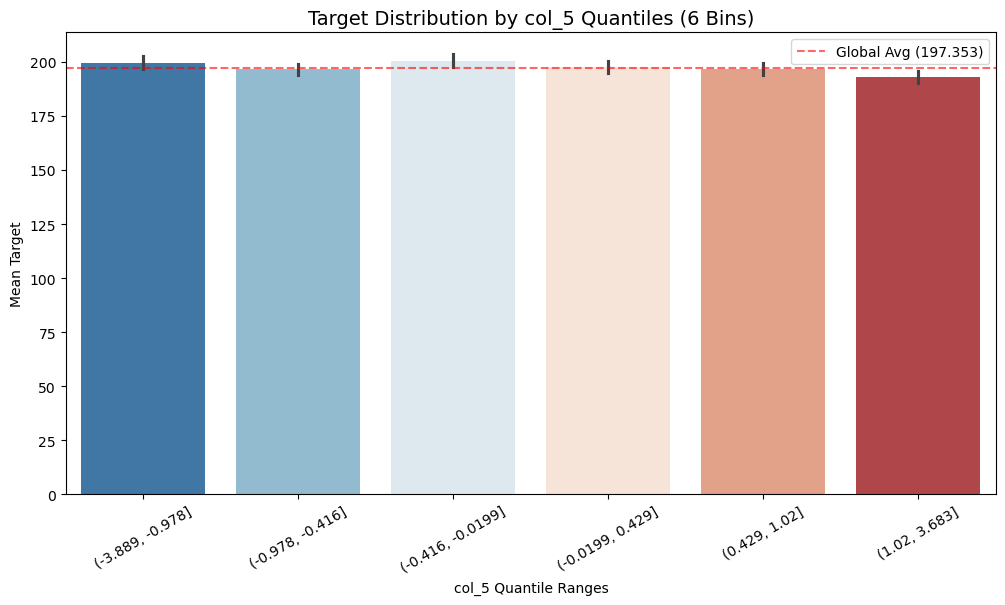

In [106]:
feature_analysis("col_5", 6)

,col_6_cut,target
0,"(-3.12, -0.92]",197.226992
1,"(-0.92, -0.39]",197.877221
2,"(-0.39, 0.0119]",197.496170
3,"(0.0119, 0.409]",197.425042
4,"(0.409, 0.949]",199.057903
5,"(0.949, 4.088]",195.041234


,mean,median,std,count,min,max,noise_ratio
col_6_cut,,,,,,,
"(-3.12, -0.92]",197.226992,195.614011,26.720304,334,107.483877,288.510777,0.135480
"(-0.92, -0.39]",197.877221,196.203879,26.599567,332,105.263432,328.614535,0.134425
"(-0.39, 0.0119]",197.496170,196.401578,26.321917,334,106.201614,281.946756,0.133278
"(0.0119, 0.409]",197.425042,195.689514,24.747471,332,121.630118,394.192258,0.125351
"(0.409, 0.949]",199.057903,196.422173,27.617124,333,80.000000,349.973208,0.138739
"(0.949, 4.088]",195.041234,194.720887,25.818843,334,87.691504,400.000000,0.132376


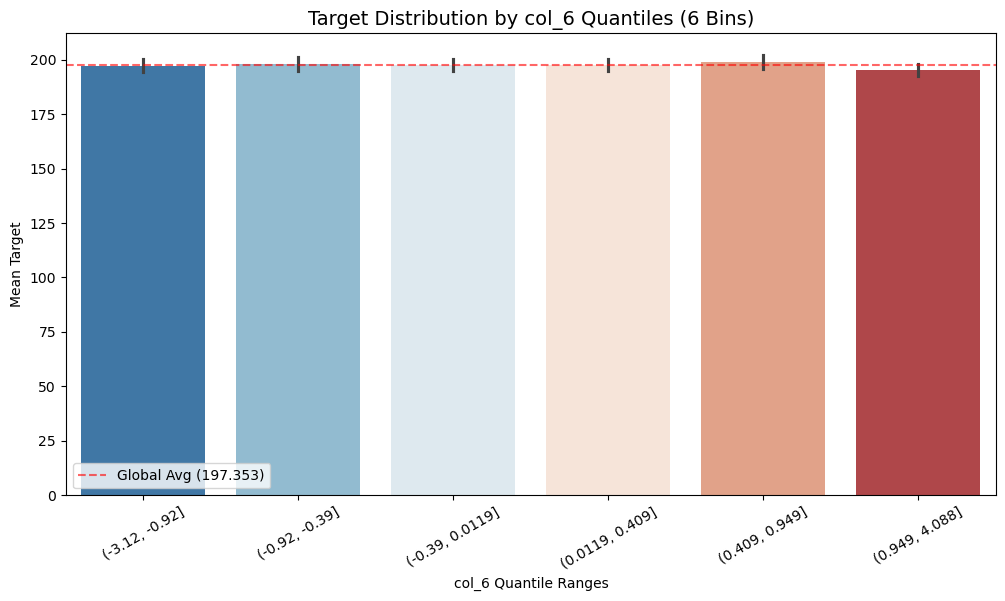

In [107]:
feature_analysis("col_6", 6)

flat median across groups

,col_7_cut,target
0,"(-3.7929999999999997, -0.999]",198.988475
1,"(-0.999, -0.419]",195.632958
2,"(-0.419, 0.00814]",197.826814
3,"(0.00814, 0.421]",197.738914
4,"(0.421, 0.978]",195.446960
5,"(0.978, 3.098]",198.468071


,mean,median,std,count,min,max,noise_ratio
col_7_cut,,,,,,,
"(-3.7929999999999997, -0.999]",198.988475,195.783796,25.951451,334,116.293378,394.192258,0.130417
"(-0.999, -0.419]",195.632958,195.774086,23.543345,332,105.263432,278.155918,0.120344
"(-0.419, 0.00814]",197.826814,195.419627,28.563648,334,87.691504,400.000000,0.144387
"(0.00814, 0.421]",197.738914,195.182780,27.076865,332,80.000000,328.614535,0.136932
"(0.421, 0.978]",195.446960,195.594370,26.685575,333,107.483877,291.436374,0.136536
"(0.978, 3.098]",198.468071,196.560671,25.778561,334,106.201614,292.416417,0.129888


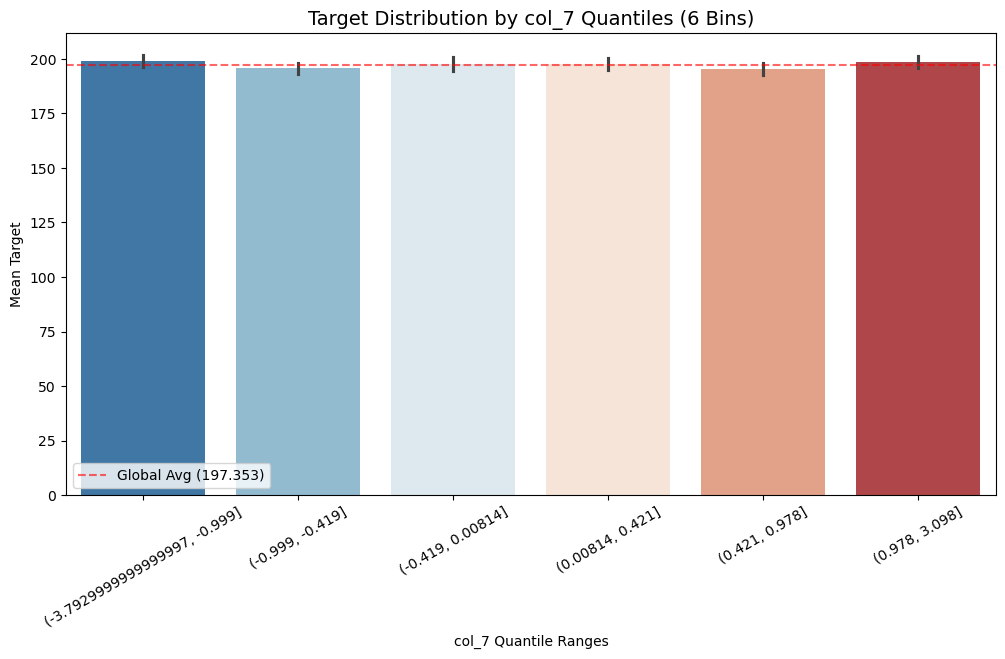

In [108]:
feature_analysis("col_7", 6)

flat median across groups.

,col_8_cut,target
0,"(-3.465, -0.97]",198.060430
1,"(-0.97, -0.461]",196.450061
2,"(-0.461, -0.0326]",197.766840
3,"(-0.0326, 0.434]",196.938112
4,"(0.434, 1.021]",196.909580
5,"(1.021, 3.868]",197.989701


,mean,median,std,count,min,max,noise_ratio
col_8_cut,,,,,,,
"(-3.465, -0.97]",198.060430,196.486886,26.790817,333,112.641142,291.436374,0.135266
"(-0.97, -0.461]",196.450061,195.471469,27.744228,333,87.691504,328.614535,0.141228
"(-0.461, -0.0326]",197.766840,195.366037,25.262849,334,110.494596,349.973208,0.127741
"(-0.0326, 0.434]",196.938112,196.505345,24.198322,332,80.000000,280.348135,0.122873
"(0.434, 1.021]",196.909580,194.884035,23.704688,334,116.293378,288.510777,0.120384
"(1.021, 3.868]",197.989701,195.886909,29.827774,333,114.085108,400.000000,0.150653


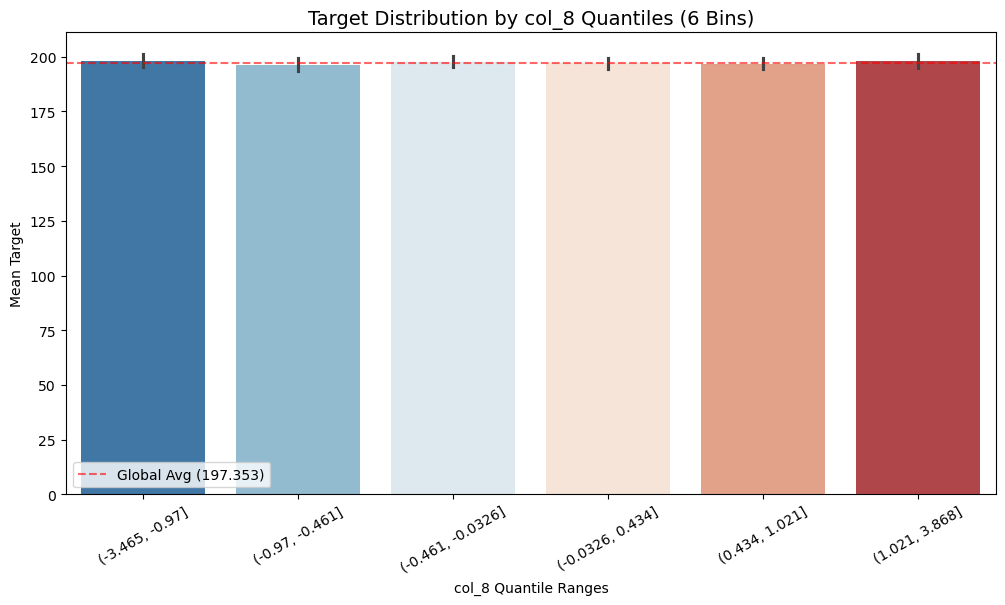

In [109]:
feature_analysis("col_8", 6)

flat median across groups.

,col_9_cut,target
0,"(-4.533, -1.3]",190.870836
1,"(-1.3, -0.843]",195.493104
2,"(-0.843, -0.551]",197.185216
3,"(-0.551, -0.273]",198.905592
4,"(-0.273, -0.00386]",195.778164
5,"(-0.00386, 0.267]",193.983970
6,"(0.267, 0.572]",198.563924
7,"(0.572, 0.857]",198.101279
8,"(0.857, 1.344]",198.821650
9,"(1.344, 3.787]",205.805891


,mean,median,std,count,min,max,noise_ratio
col_9_cut,,,,,,,
"(-4.533, -1.3]",190.870836,193.514311,25.753181,200,87.691504,269.258083,0.134925
"(-1.3, -0.843]",195.493104,194.542213,25.571483,200,80.000000,281.946756,0.130805
"(-0.843, -0.551]",197.185216,195.101034,24.150194,200,122.585263,394.192258,0.122475
"(-0.551, -0.273]",198.905592,196.419778,22.913048,200,127.813871,288.510777,0.115196
"(-0.273, -0.00386]",195.778164,196.196253,18.772770,200,123.608019,258.569741,0.095888
"(-0.00386, 0.267]",193.983970,194.305148,25.346435,199,112.641142,287.042407,0.130663
"(0.267, 0.572]",198.563924,196.484664,25.688019,200,119.569057,298.702722,0.129369
"(0.572, 0.857]",198.101279,196.035719,26.507132,200,126.431347,292.860631,0.133806
"(0.857, 1.344]",198.821650,197.339905,24.625329,200,108.366523,273.282951,0.123856


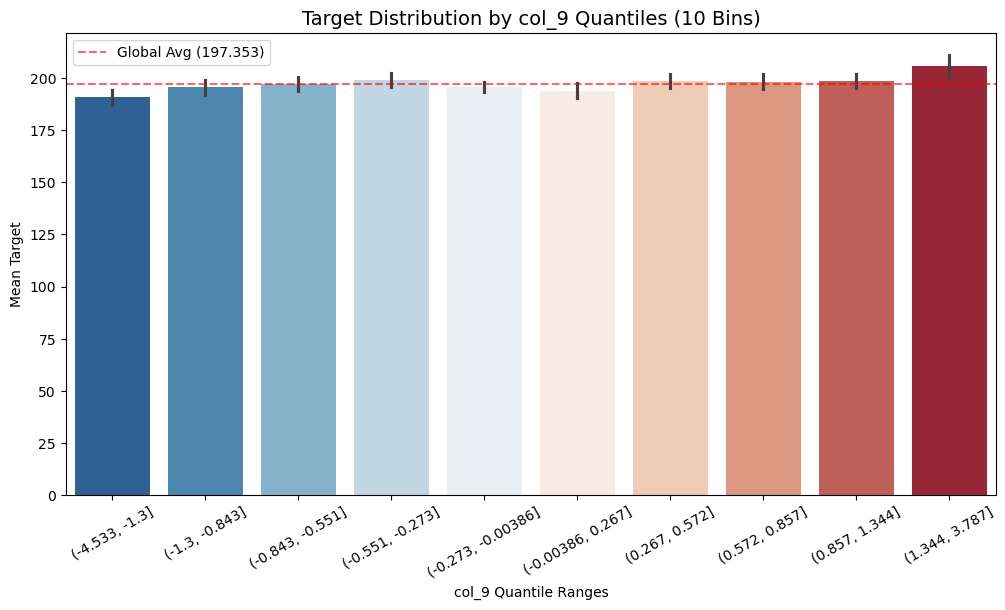

In [23]:
feature_analysis("col_9", 10)

,col_10_cut,target
0,"(-3.8729999999999998, -1.41]",197.990435
1,"(-1.41, -0.87]",198.995068
2,"(-0.87, -0.54]",197.542290
3,"(-0.54, -0.27]",196.979047
4,"(-0.27, 0.00869]",195.695693
5,"(0.00869, 0.259]",197.944612
6,"(0.259, 0.567]",197.161063
7,"(0.567, 0.897]",197.998052
8,"(0.897, 1.327]",200.628682
9,"(1.327, 3.551]",192.594489


,mean,median,std,count,min,max,noise_ratio
col_10_cut,,,,,,,
"(-3.8729999999999998, -1.41]",197.990435,197.762890,26.480035,200,106.201614,288.510777,0.133744
"(-1.41, -0.87]",198.995068,197.749596,21.933075,200,114.736771,273.282951,0.110219
"(-0.87, -0.54]",197.542290,196.249917,27.246221,200,108.665528,292.860631,0.137926
"(-0.54, -0.27]",196.979047,195.654829,26.938821,200,120.659337,394.192258,0.136760
"(-0.27, 0.00869]",195.695693,194.130161,25.618674,200,107.483877,286.771919,0.130911
"(0.00869, 0.259]",197.944612,195.886909,26.960763,199,80.000000,400.000000,0.136204
"(0.259, 0.567]",197.161063,195.151263,25.102166,200,108.366523,298.702722,0.127318
"(0.567, 0.897]",197.998052,196.079004,26.279616,200,87.691504,292.416417,0.132727
"(0.897, 1.327]",200.628682,195.652888,26.756034,200,126.431347,349.973208,0.133361


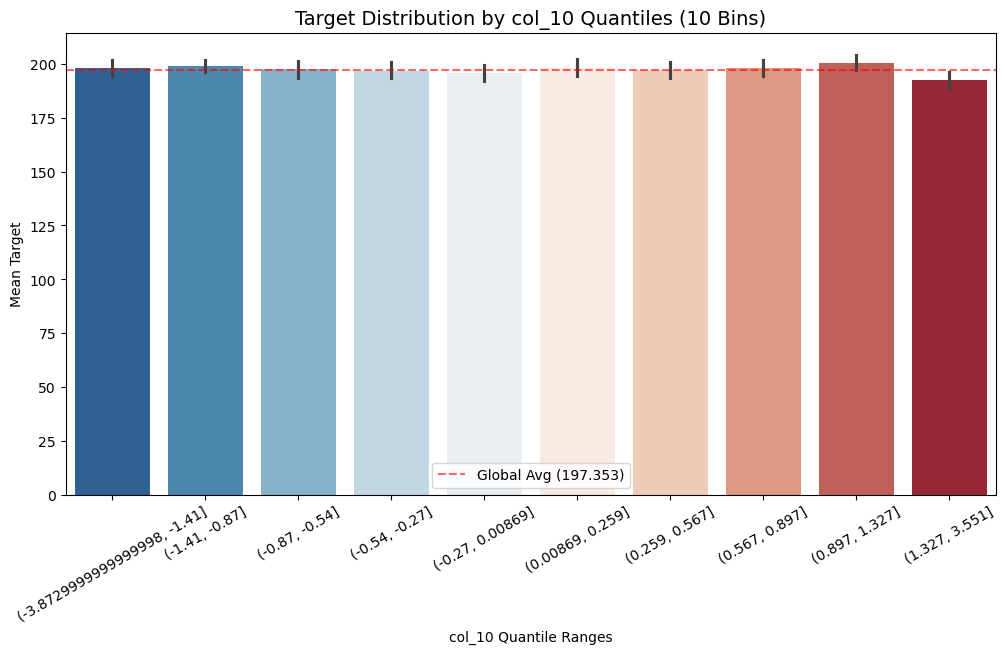

In [24]:
feature_analysis("col_10", 10)

,col_11_cut,target
0,"(-4.25, -1.031]",199.459579
1,"(-1.031, -0.468]",198.209884
2,"(-0.468, -0.0129]",198.991352
3,"(-0.0129, 0.453]",196.577981
4,"(0.453, 1.072]",197.151021
5,"(1.072, 3.513]",193.732037


,mean,median,std,count,min,max,noise_ratio
col_11_cut,,,,,,,
"(-4.25, -1.031]",199.459579,197.410734,27.812162,333,110.494596,394.192258,0.139438
"(-1.031, -0.468]",198.209884,196.111295,26.494493,334,107.483877,292.860631,0.133669
"(-0.468, -0.0129]",198.991352,195.889363,26.792039,333,112.641142,400.000000,0.134639
"(-0.0129, 0.453]",196.577981,195.819261,23.458571,332,112.734726,267.689598,0.119335
"(0.453, 1.072]",197.151021,196.390961,29.165214,333,80.000000,349.973208,0.147933
"(1.072, 3.513]",193.732037,193.454366,23.429941,334,106.201614,276.022298,0.120940


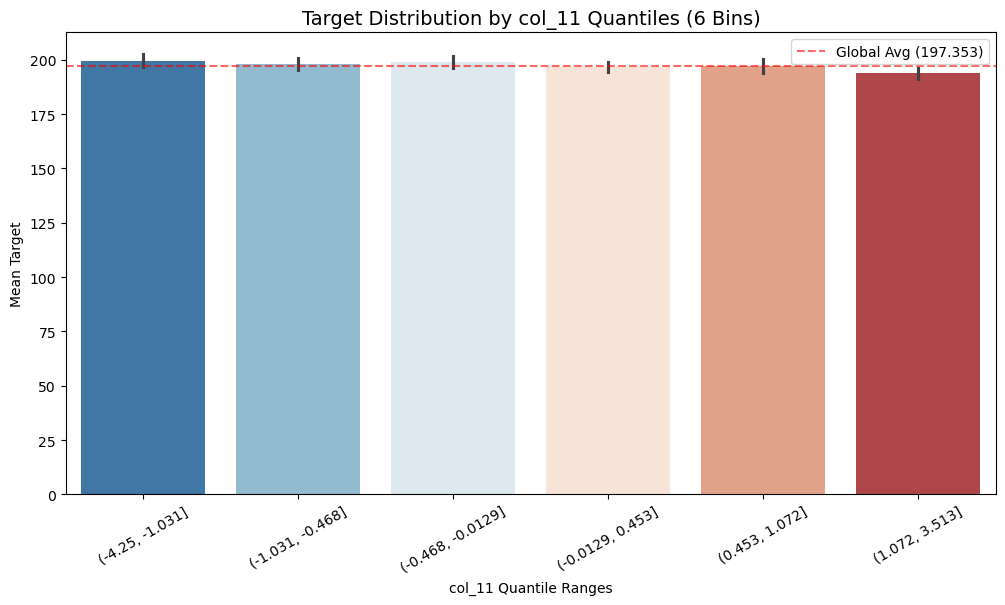

In [111]:
feature_analysis("col_11", 6)

,col_12_cut,target
0,"(-3.8049999999999997, -1.013]",198.728264
1,"(-1.013, -0.477]",198.035281
2,"(-0.477, -0.0208]",195.978411
3,"(-0.0208, 0.451]",196.820329
4,"(0.451, 1.087]",196.136535
5,"(1.087, 3.671]",198.416396


,mean,median,std,count,min,max,noise_ratio
col_12_cut,,,,,,,
"(-3.8049999999999997, -1.013]",198.728264,197.066502,26.434063,333,112.734726,291.436374,0.133016
"(-1.013, -0.477]",198.035281,196.420136,25.789869,333,87.691504,298.702722,0.130229
"(-0.477, -0.0208]",195.978411,194.192532,27.014075,334,106.201614,349.973208,0.137842
"(-0.0208, 0.451]",196.820329,195.733590,25.379844,332,108.366523,288.510777,0.128949
"(0.451, 1.087]",196.136535,194.985303,23.313413,333,80.000000,265.272262,0.118863
"(1.087, 3.671]",198.416396,196.144321,29.591107,334,114.085108,400.000000,0.149136


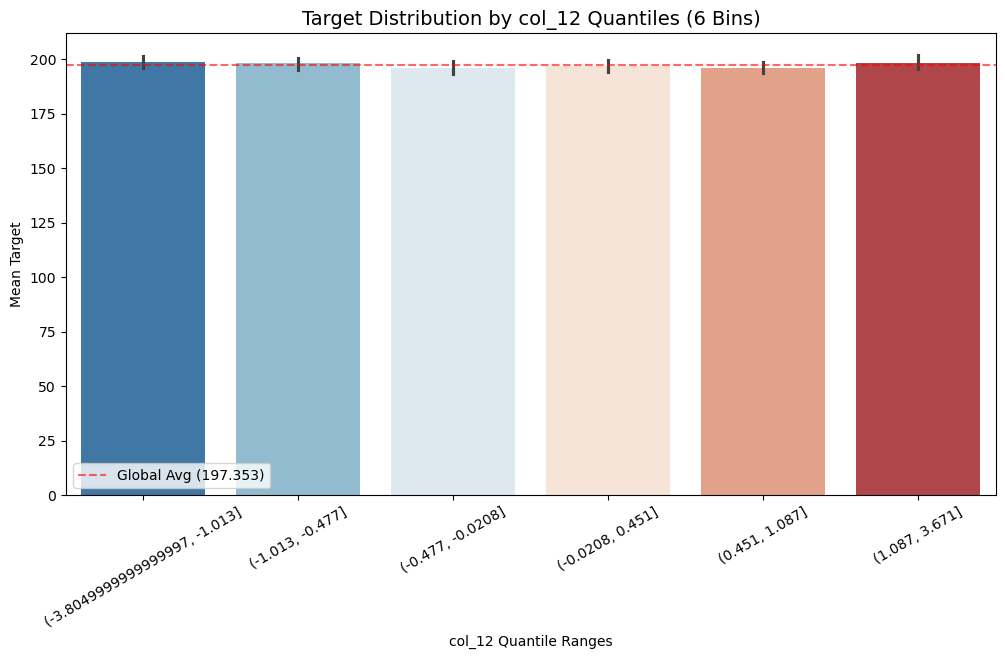

In [112]:
feature_analysis("col_12", 6)

flat median across groups.

,col_13_cut,target
0,"(-4.182, -1.051]",197.296202
1,"(-1.051, -0.453]",197.512157
2,"(-0.453, 0.00496]",197.476124
3,"(0.00496, 0.441]",197.568655
4,"(0.441, 1.015]",197.572193
5,"(1.015, 3.717]",196.692809


,mean,median,std,count,min,max,noise_ratio
col_13_cut,,,,,,,
"(-4.182, -1.051]",197.296202,195.854566,25.584496,333,105.263432,394.192258,0.129676
"(-1.051, -0.453]",197.512157,195.103021,23.852210,333,114.085108,285.090376,0.120763
"(-0.453, 0.00496]",197.476124,195.541596,27.902309,334,80.000000,400.000000,0.141295
"(0.00496, 0.441]",197.568655,195.401157,28.434906,332,87.691504,349.973208,0.143924
"(0.441, 1.015]",197.572193,197.000649,27.104299,333,107.483877,328.614535,0.137187
"(1.015, 3.717]",196.692809,195.934892,24.888067,334,106.201614,292.416417,0.126533


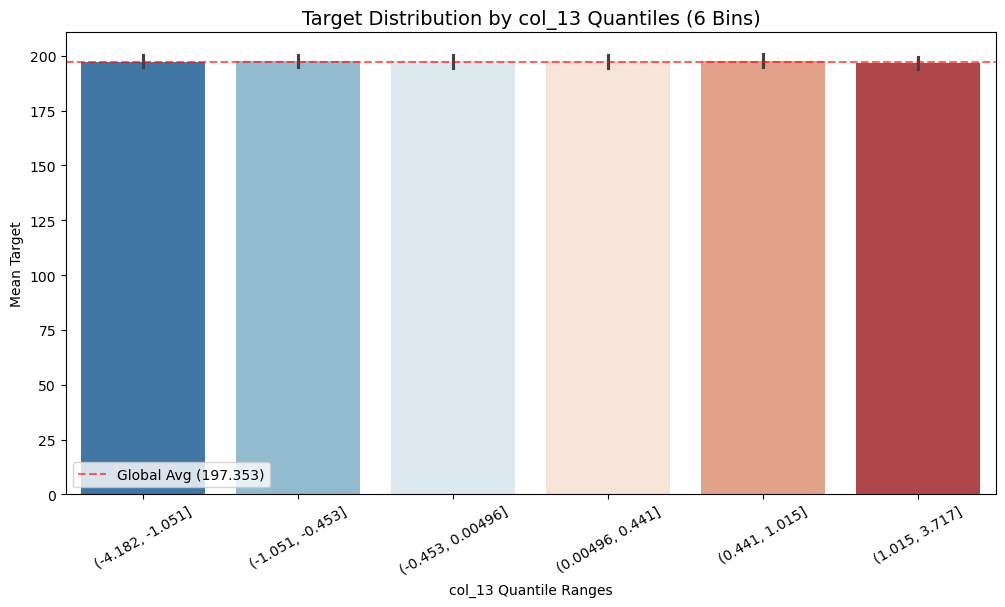

In [113]:
feature_analysis("col_13", 6)

,col_14_cut,target
0,"(-4.442, -1.064]",198.565793
1,"(-1.064, -0.463]",197.524474
2,"(-0.463, 0.00912]",196.789920
3,"(0.00912, 0.439]",197.090579
4,"(0.439, 1.057]",196.815102
5,"(1.057, 3.814]",197.330983


,mean,median,std,count,min,max,noise_ratio
col_14_cut,,,,,,,
"(-4.442, -1.064]",198.565793,195.667259,26.735675,333,116.293378,394.192258,0.134644
"(-1.064, -0.463]",197.524474,196.129223,23.094170,333,105.263432,288.510777,0.116918
"(-0.463, 0.00912]",196.789920,196.041330,27.688010,334,87.691504,349.973208,0.140698
"(0.00912, 0.439]",197.090579,195.966497,27.872433,332,80.000000,400.000000,0.141419
"(0.439, 1.057]",196.815102,194.982474,26.795494,333,107.483877,298.702722,0.136146
"(1.057, 3.814]",197.330983,196.090404,25.558452,334,106.201614,292.416417,0.129521


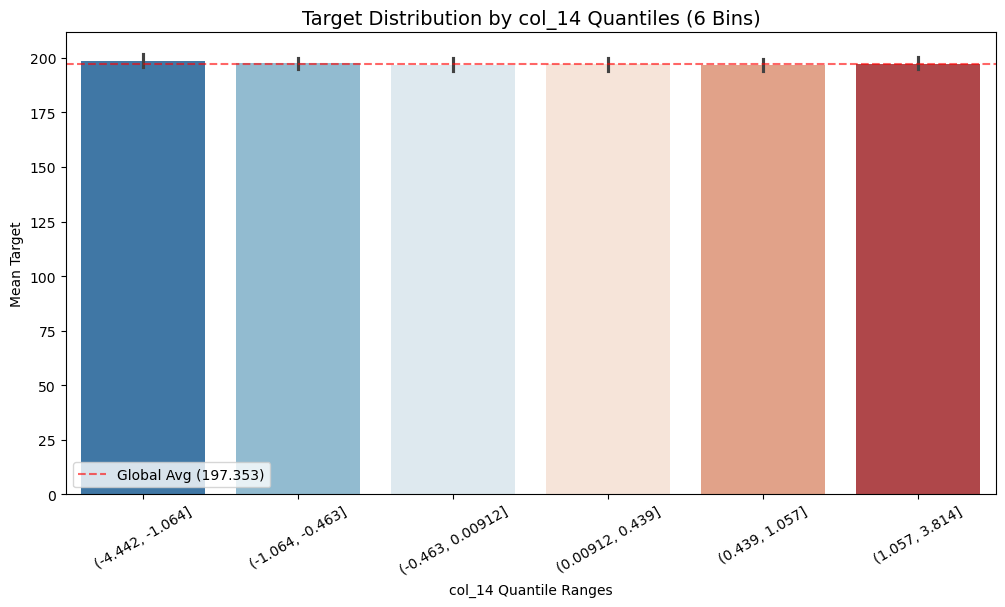

In [114]:
feature_analysis("col_14", 6)

flat median across groups.

,col_15_cut,target
0,"(-3.56, -1.036]",197.886087
1,"(-1.036, -0.478]",196.450809
2,"(-0.478, -0.0166]",199.217479
3,"(-0.0166, 0.485]",195.755724
4,"(0.485, 1.089]",196.455931
5,"(1.089, 4.094]",198.346148


,mean,median,std,count,min,max,noise_ratio
col_15_cut,,,,,,,
"(-3.56, -1.036]",197.886087,196.834635,27.808727,334,87.691504,291.436374,0.140529
"(-1.036, -0.478]",196.450809,194.719415,25.711772,333,105.263432,328.614535,0.130881
"(-0.478, -0.0166]",199.217479,196.058393,26.243015,333,106.201614,349.973208,0.131730
"(-0.0166, 0.485]",195.755724,196.134169,24.270300,332,80.000000,269.868732,0.123983
"(0.485, 1.089]",196.455931,194.539903,23.210644,334,127.813871,288.510777,0.118147
"(1.089, 4.094]",198.346148,195.889363,30.082780,333,114.085108,400.000000,0.151668


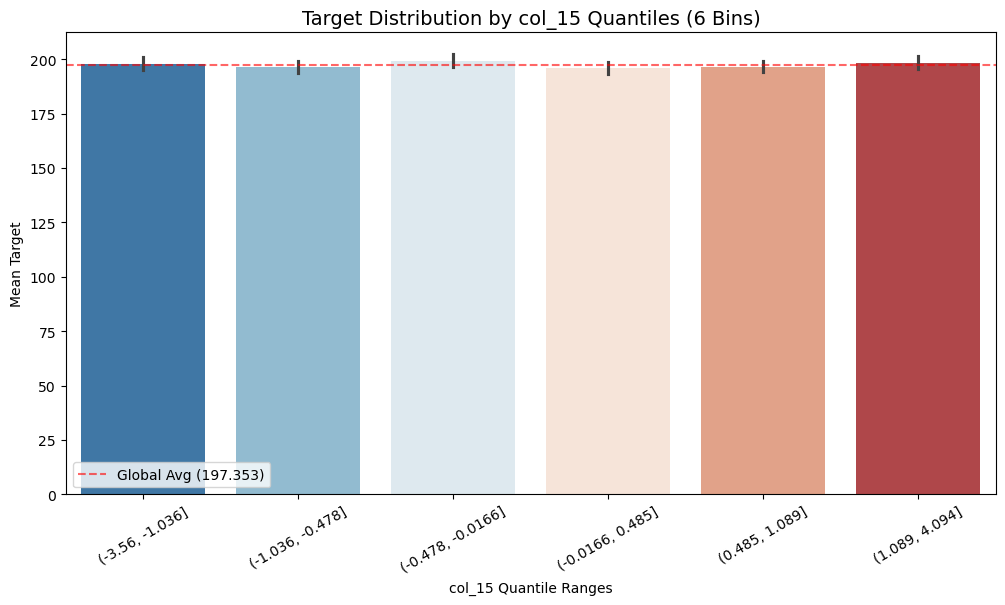

In [115]:
feature_analysis("col_15", 6)

no trend

,col_15_cut,target
0,"(-3.56, -1.036]",197.886087
1,"(-1.036, -0.478]",196.450809
2,"(-0.478, -0.0166]",199.217479
3,"(-0.0166, 0.485]",195.755724
4,"(0.485, 1.089]",196.455931
5,"(1.089, 4.094]",198.346148


,mean,median,std,count,min,max,noise_ratio
col_15_cut,,,,,,,
"(-3.56, -1.036]",197.886087,196.834635,27.808727,334,87.691504,291.436374,0.140529
"(-1.036, -0.478]",196.450809,194.719415,25.711772,333,105.263432,328.614535,0.130881
"(-0.478, -0.0166]",199.217479,196.058393,26.243015,333,106.201614,349.973208,0.131730
"(-0.0166, 0.485]",195.755724,196.134169,24.270300,332,80.000000,269.868732,0.123983
"(0.485, 1.089]",196.455931,194.539903,23.210644,334,127.813871,288.510777,0.118147
"(1.089, 4.094]",198.346148,195.889363,30.082780,333,114.085108,400.000000,0.151668


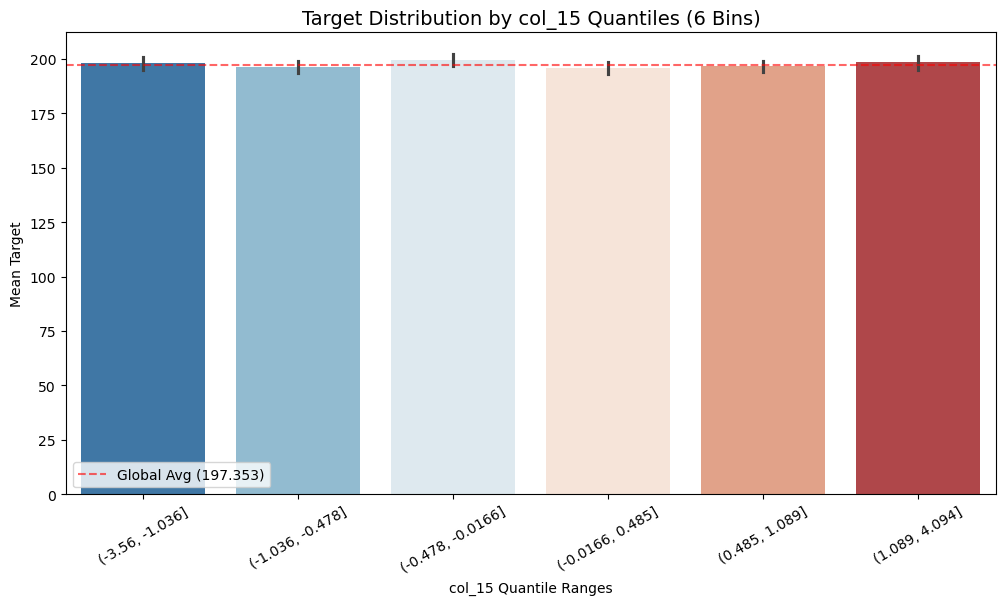

In [116]:
feature_analysis("col_15", 6)

no trend

,col_16_cut,target
0,"(-3.541, -1.029]",198.800188
1,"(-1.029, -0.485]",197.912754
2,"(-0.485, 0.0182]",195.430261
3,"(0.0182, 0.438]",197.433956
4,"(0.438, 1.018]",196.456234
5,"(1.018, 3.506]",198.086304


,mean,median,std,count,min,max,noise_ratio
col_16_cut,,,,,,,
"(-3.541, -1.029]",198.800188,195.666793,27.042409,333,105.263432,394.192258,0.136028
"(-1.029, -0.485]",197.912754,196.539300,25.146368,333,114.085108,349.973208,0.127058
"(-0.485, 0.0182]",195.430261,194.967848,28.070621,334,87.691504,400.000000,0.143635
"(0.0182, 0.438]",197.433956,195.061984,26.064103,332,80.000000,328.614535,0.132014
"(0.438, 1.018]",196.456234,195.889363,24.945156,333,107.483877,277.500687,0.126976
"(1.018, 3.506]",198.086304,196.410264,26.530418,334,106.201614,292.416417,0.133934


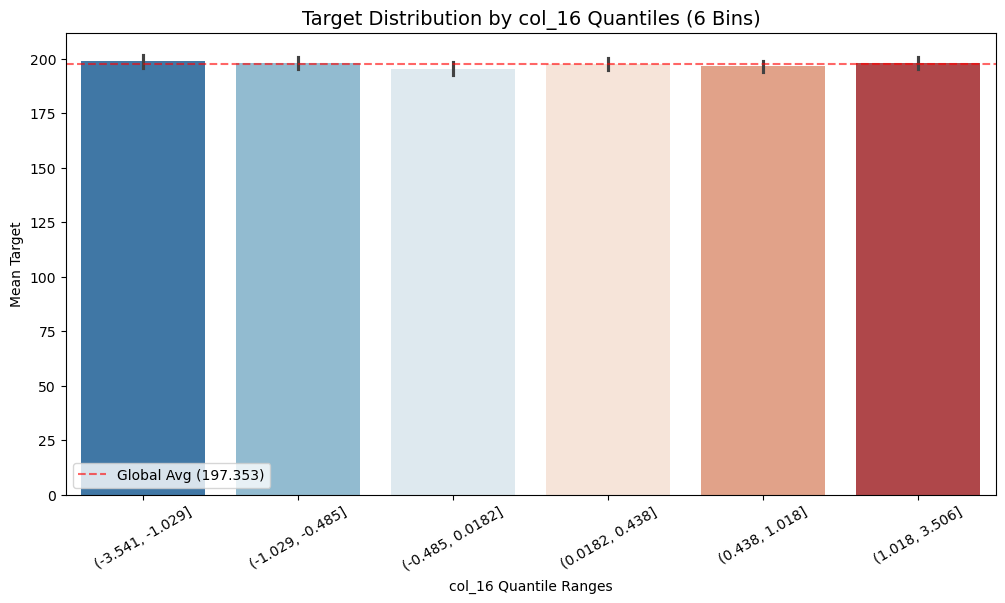

In [119]:
feature_analysis("col_16", 6)

no trend

,col_17_cut,target
0,"(-4.297000000000001, -1.007]",200.018856
1,"(-1.007, -0.421]",196.803852
2,"(-0.421, 0.00855]",199.901175
3,"(0.00855, 0.469]",198.149375
4,"(0.469, 1.072]",196.848261
5,"(1.072, 3.826]",192.403964


,mean,median,std,count,min,max,noise_ratio
col_17_cut,,,,,,,
"(-4.297000000000001, -1.007]",200.018856,197.124197,28.358867,333,108.366523,394.192258,0.141781
"(-1.007, -0.421]",196.803852,195.800388,23.471932,333,107.483877,292.860631,0.119266
"(-0.421, 0.00855]",199.901175,196.555569,28.865348,334,108.665528,400.000000,0.144398
"(0.00855, 0.469]",198.149375,196.227451,24.988730,332,116.293378,328.614535,0.126111
"(0.469, 1.072]",196.848261,195.610016,25.111447,333,114.736771,285.090376,0.127568
"(1.072, 3.826]",192.403964,193.120298,26.104161,334,80.000000,287.042407,0.135674


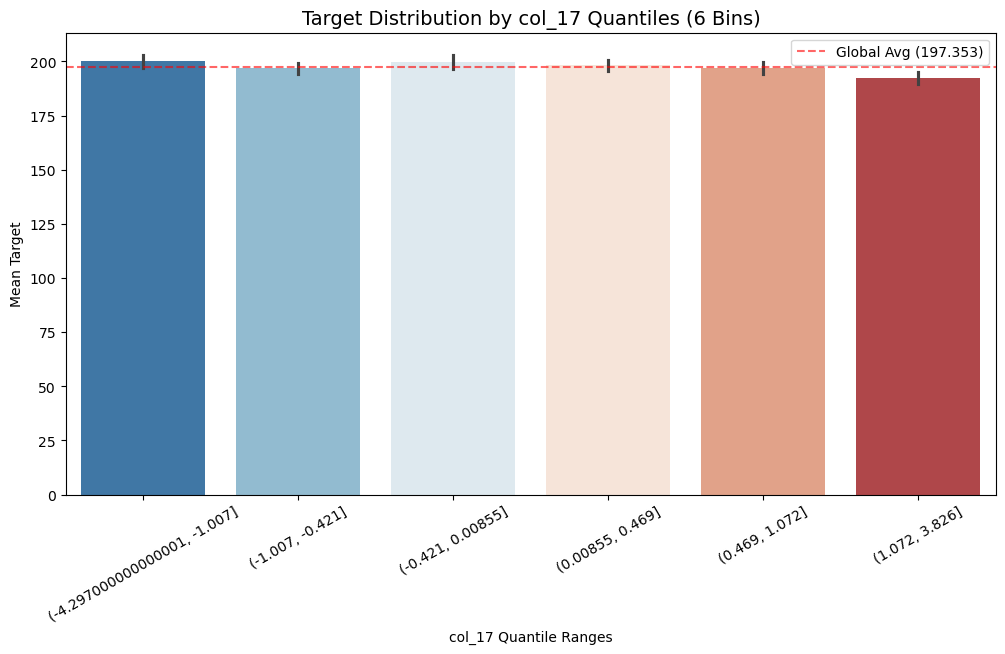

In [120]:
feature_analysis("col_17", 6)

In [121]:
df['col_17_high'] = (df['col_17'] > 1.072).astype(int)

,col_18_cut,target
0,"(-4.353000000000001, -1.34]",191.301064
1,"(-1.34, -0.856]",196.046432
2,"(-0.856, -0.554]",194.406741
3,"(-0.554, -0.254]",197.043306
4,"(-0.254, -0.0201]",198.500747
5,"(-0.0201, 0.24]",195.572320
6,"(0.24, 0.518]",199.929023
7,"(0.518, 0.884]",198.670340
8,"(0.884, 1.377]",197.017637
9,"(1.377, 3.561]",205.029957


,mean,median,std,count,min,max,noise_ratio
col_18_cut,,,,,,,
"(-4.353000000000001, -1.34]",191.301064,193.745354,30.540224,200,87.691504,394.192258,0.159645
"(-1.34, -0.856]",196.046432,195.437772,22.624314,200,80.000000,268.617677,0.115403
"(-0.856, -0.554]",194.406741,193.831728,24.522572,200,112.641142,291.436374,0.126141
"(-0.554, -0.254]",197.043306,195.324787,20.660835,200,122.163522,266.363668,0.104854
"(-0.254, -0.0201]",198.500747,195.515500,22.403083,200,115.777105,287.042407,0.112861
"(-0.0201, 0.24]",195.572320,194.526746,22.222891,199,114.736771,292.860631,0.113630
"(0.24, 0.518]",199.929023,196.552865,27.059493,200,123.608019,298.702722,0.135345
"(0.518, 0.884]",198.670340,196.961517,21.868660,200,120.154795,272.913214,0.110075
"(0.884, 1.377]",197.017637,195.684277,28.019232,200,108.366523,273.428468,0.142217


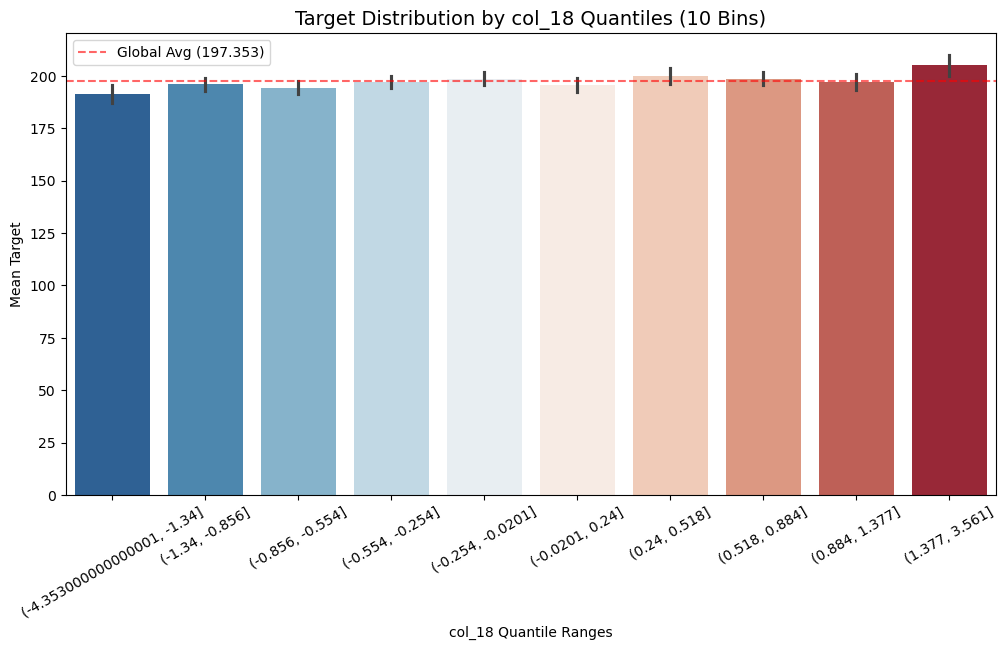

In [34]:
feature_analysis("col_18", 10)

,col_19_cut,target
0,"(-3.274, -1.338]",194.021622
1,"(-1.338, -0.877]",197.013890
2,"(-0.877, -0.562]",198.593511
3,"(-0.562, -0.274]",196.481633
4,"(-0.274, -0.0273]",196.104198
5,"(-0.0273, 0.272]",197.114642
6,"(0.272, 0.573]",198.469604
7,"(0.573, 0.942]",198.184949
8,"(0.942, 1.356]",197.586024
9,"(1.356, 3.699]",199.955208


,mean,median,std,count,min,max,noise_ratio
col_19_cut,,,,,,,
"(-3.274, -1.338]",194.021622,194.471920,23.126554,200,108.665528,269.258083,0.119196
"(-1.338, -0.877]",197.013890,194.785168,23.653414,200,119.569057,292.860631,0.120060
"(-0.877, -0.562]",198.593511,197.547268,24.541003,200,105.263432,290.140708,0.123574
"(-0.562, -0.274]",196.481633,196.187722,20.328952,200,116.253370,276.022298,0.103465
"(-0.274, -0.0273]",196.104198,195.222884,26.058604,200,116.866950,277.500687,0.132881
"(-0.0273, 0.272]",197.114642,195.785795,28.547917,199,87.691504,349.973208,0.144829
"(0.272, 0.573]",198.469604,195.098554,26.158808,200,120.154795,288.510777,0.131803
"(0.573, 0.942]",198.184949,195.738729,22.570703,200,135.764737,287.042407,0.113887
"(0.942, 1.356]",197.586024,197.066983,32.743990,200,112.641142,394.192258,0.165720


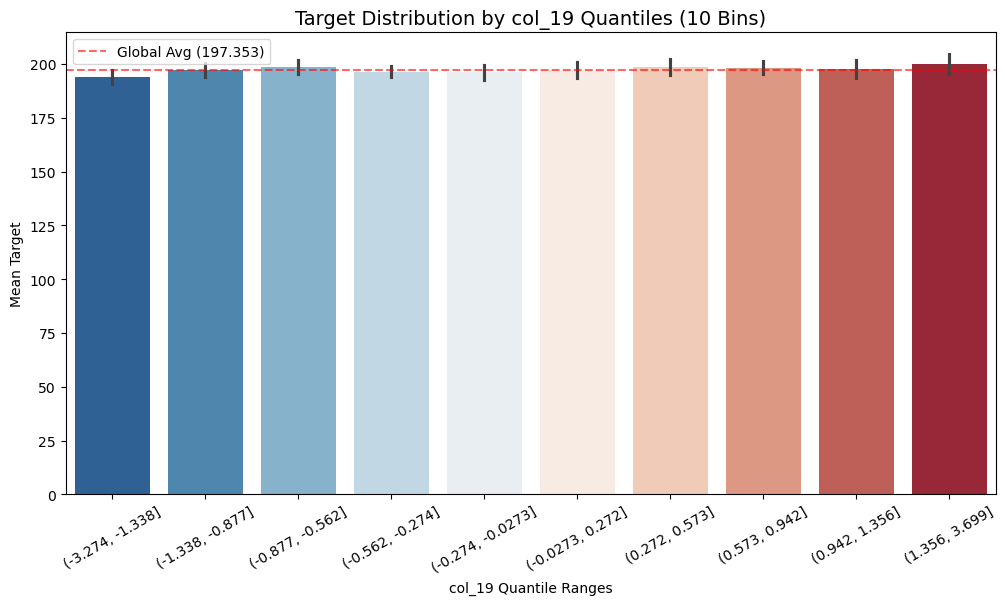

In [35]:
feature_analysis("col_19", 10)

,col_20_cut,target
0,"(-3.343, -1.234]",198.941586
1,"(-1.234, -0.719]",196.961483
2,"(-0.719, -0.373]",197.568985
3,"(-0.373, -0.0376]",197.898448
4,"(-0.0376, 0.316]",199.037196
5,"(0.316, 0.704]",195.652636
6,"(0.704, 1.223]",196.076625
7,"(1.223, 3.287]",196.690956


,mean,median,std,count,min,max,noise_ratio
col_20_cut,,,,,,,
"(-3.343, -1.234]",198.941586,196.522731,25.053731,250,106.201614,288.510777,0.125935
"(-1.234, -0.719]",196.961483,196.975606,25.179223,250,114.736771,291.436374,0.127838
"(-0.719, -0.373]",197.568985,196.809340,27.087755,250,80.000000,298.702722,0.137105
"(-0.373, -0.0376]",197.898448,195.967705,26.238359,250,108.665528,394.192258,0.132585
"(-0.0376, 0.316]",199.037196,194.931314,27.442776,249,107.483877,400.000000,0.137878
"(0.316, 0.704]",195.652636,195.126900,23.526216,250,108.366523,278.155918,0.120245
"(0.704, 1.223]",196.076625,195.059322,25.466692,250,105.263432,292.416417,0.129881
"(1.223, 3.287]",196.690956,195.588960,30.151930,250,87.691504,349.973208,0.153296


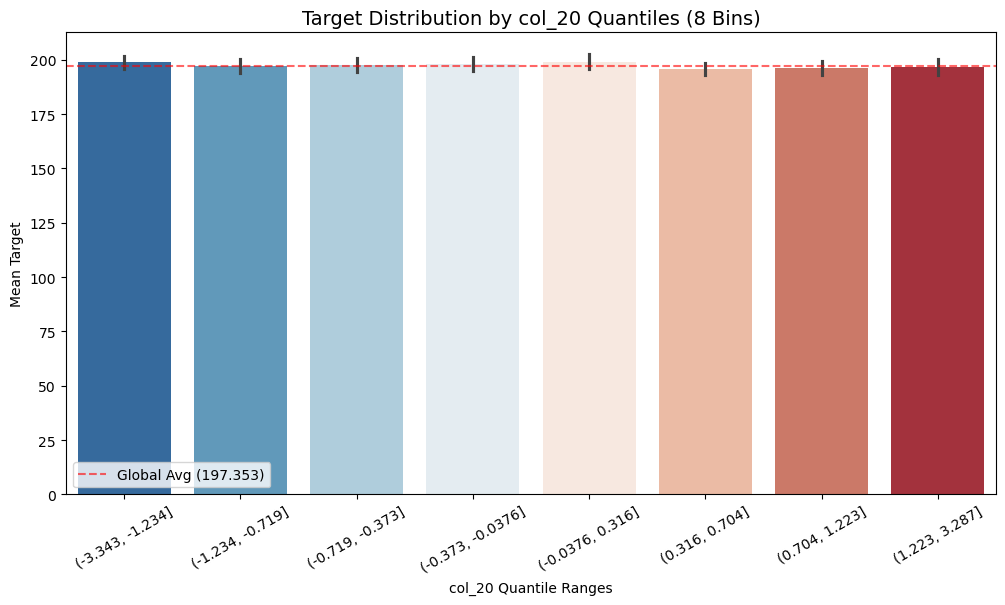

In [37]:
feature_analysis("col_20", 8)

,col_21_cut,target
0,"(-5.179, -1.318]",191.718449
1,"(-1.318, -0.843]",195.295782
2,"(-0.843, -0.52]",197.719272
3,"(-0.52, -0.276]",194.572048
4,"(-0.276, 0.00945]",196.869281
5,"(0.00945, 0.271]",196.800241
6,"(0.271, 0.564]",195.529428
7,"(0.564, 0.891]",199.150061
8,"(0.891, 1.364]",201.194417
9,"(1.364, 3.88]",204.674728


,mean,median,std,count,min,max,noise_ratio
col_21_cut,,,,,,,
"(-5.179, -1.318]",191.718449,193.856939,27.160482,200,80.000000,269.258083,0.141669
"(-1.318, -0.843]",195.295782,194.408372,26.832356,200,106.201614,394.192258,0.137393
"(-0.843, -0.52]",197.719272,196.125256,21.718051,200,131.361387,298.702722,0.109843
"(-0.52, -0.276]",194.572048,194.087800,18.882252,200,114.736771,261.368534,0.097045
"(-0.276, 0.00945]",196.869281,194.553691,23.445502,200,122.163522,290.140708,0.119092
"(0.00945, 0.271]",196.800241,195.833931,23.819462,199,115.777105,286.771919,0.121034
"(0.271, 0.564]",195.529428,194.418078,27.885704,200,110.494596,292.860631,0.142616
"(0.564, 0.891]",199.150061,197.306823,25.423846,200,119.569057,280.348135,0.127662
"(0.891, 1.364]",201.194417,197.968182,27.646660,200,116.293378,286.592472,0.137413


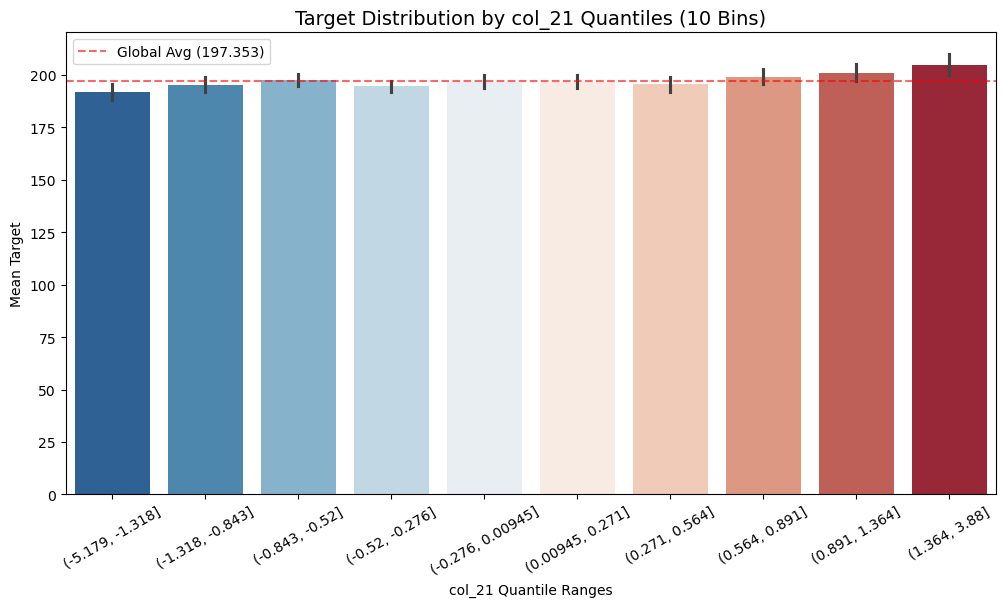

In [38]:
feature_analysis("col_21", 10)

,col_22_cut,target
0,"(-3.895, -1.358]",200.723786
1,"(-1.358, -0.917]",196.949829
2,"(-0.917, -0.571]",198.967128
3,"(-0.571, -0.284]",199.857679
4,"(-0.284, -0.0221]",197.116902
5,"(-0.0221, 0.246]",199.627659
6,"(0.246, 0.547]",193.227083
7,"(0.547, 0.899]",200.201870
8,"(0.899, 1.409]",193.481148
9,"(1.409, 3.694]",193.384760


,mean,median,std,count,min,max,noise_ratio
col_22_cut,,,,,,,
"(-3.895, -1.358]",200.723786,197.302730,26.657764,200,134.517385,394.192258,0.132808
"(-1.358, -0.917]",196.949829,195.632990,25.899868,200,116.866950,286.592472,0.131505
"(-0.917, -0.571]",198.967128,197.127866,26.707641,200,110.494596,298.702722,0.134231
"(-0.571, -0.284]",199.857679,198.772426,26.947053,200,108.366523,288.510777,0.134831
"(-0.284, -0.0221]",197.116902,195.173776,23.657306,200,112.734726,273.747141,0.120017
"(-0.0221, 0.246]",199.627659,196.760294,24.242907,199,116.293378,349.973208,0.121441
"(0.246, 0.547]",193.227083,194.385938,28.973723,200,80.000000,290.140708,0.149946
"(0.547, 0.899]",200.201870,196.817411,27.724623,200,114.736771,400.000000,0.138483
"(0.899, 1.409]",193.481148,192.985522,27.016545,200,105.263432,328.614535,0.139634


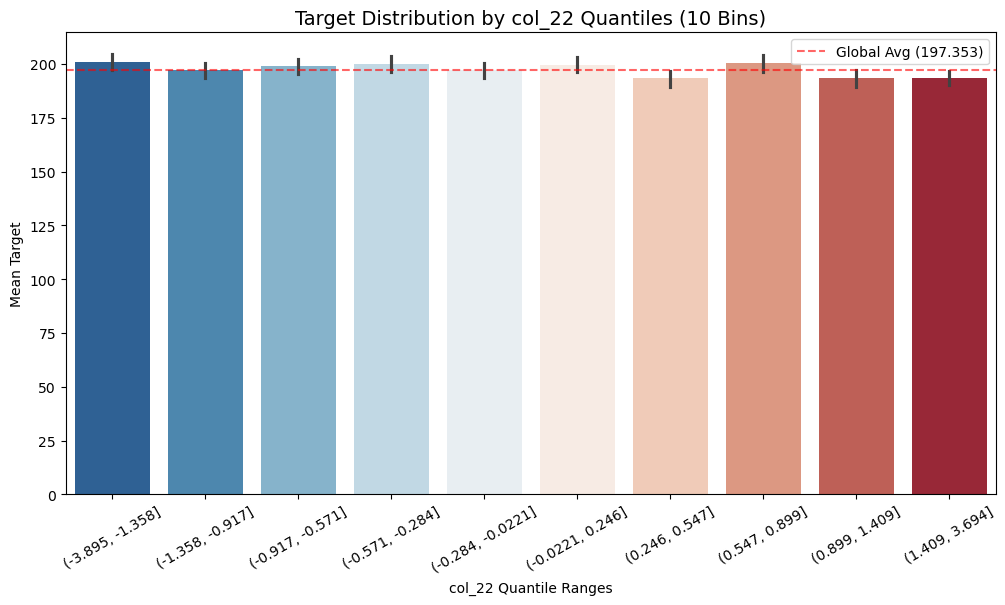

In [39]:
feature_analysis("col_22", 10)

,col_23_cut,target
0,"(-3.778, -1.339]",196.250191
1,"(-1.339, -0.897]",196.445969
2,"(-0.897, -0.569]",196.054097
3,"(-0.569, -0.29]",196.844998
4,"(-0.29, 0.00948]",196.689276
5,"(0.00948, 0.283]",196.460278
6,"(0.283, 0.577]",199.169619
7,"(0.577, 0.886]",198.973728
8,"(0.886, 1.393]",196.847686
9,"(1.393, 3.803]",199.786164


,mean,median,std,count,min,max,noise_ratio
col_23_cut,,,,,,,
"(-3.778, -1.339]",196.250191,194.803409,21.250915,200,108.665528,281.946756,0.108285
"(-1.339, -0.897]",196.445969,196.105401,24.438145,200,110.494596,292.860631,0.124401
"(-0.897, -0.569]",196.054097,195.524647,22.342995,200,105.263432,266.564527,0.113963
"(-0.569, -0.29]",196.844998,195.419627,24.947982,200,116.253370,290.140708,0.126739
"(-0.29, 0.00948]",196.689276,195.298703,23.973748,200,110.857473,280.140598,0.121886
"(0.00948, 0.283]",196.460278,195.696515,31.081656,199,87.691504,349.973208,0.158208
"(0.283, 0.577]",199.169619,195.864415,23.085864,200,143.088158,273.747141,0.115911
"(0.577, 0.886]",198.973728,198.520346,25.140453,200,106.201614,286.592472,0.126351
"(0.886, 1.393]",196.847686,196.230649,31.493759,200,112.641142,400.000000,0.159990


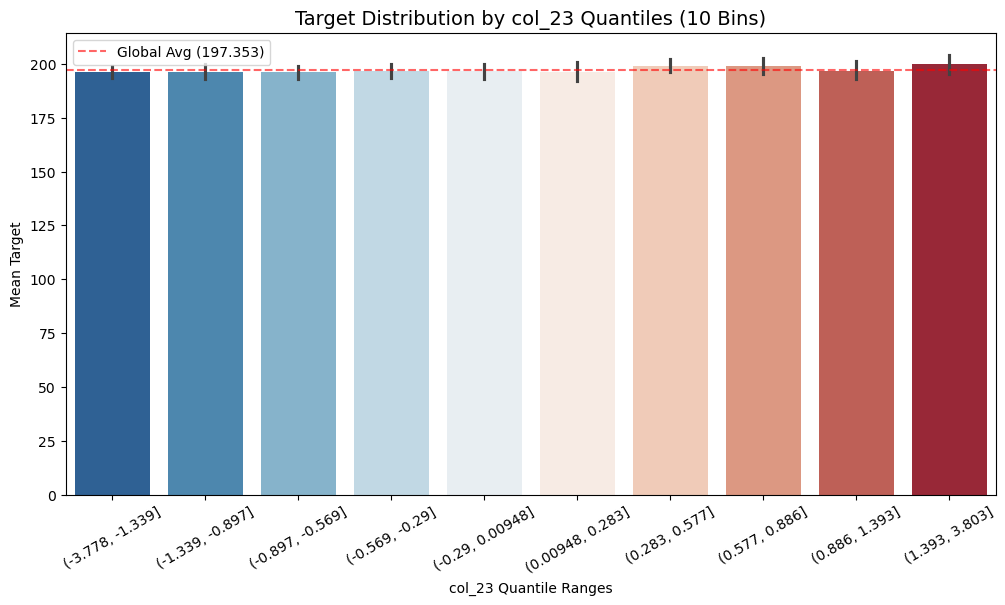

In [40]:
feature_analysis("col_23", 10)

,col_24_cut,target
0,"(-3.25, -1.285]",197.200376
1,"(-1.285, -0.848]",198.974291
2,"(-0.848, -0.519]",193.106037
3,"(-0.519, -0.243]",199.584640
4,"(-0.243, 0.029]",196.728346
5,"(0.029, 0.259]",200.953720
6,"(0.259, 0.537]",197.977292
7,"(0.537, 0.925]",196.922448
8,"(0.925, 1.364]",197.373583
9,"(1.364, 4.25]",194.723742


,mean,median,std,count,min,max,noise_ratio
col_24_cut,,,,,,,
"(-3.25, -1.285]",197.200376,195.527571,25.137955,200,107.483877,285.090376,0.127474
"(-1.285, -0.848]",198.974291,196.786313,25.082142,200,108.366523,277.314646,0.126057
"(-0.848, -0.519]",193.106037,193.755377,28.436215,200,105.263432,298.702722,0.147257
"(-0.519, -0.243]",199.584640,196.645253,26.445142,200,108.665528,290.140708,0.132501
"(-0.243, 0.029]",196.728346,194.472719,24.906282,200,115.777105,328.614535,0.126602
"(0.029, 0.259]",200.953720,198.035022,27.613793,199,119.573770,394.192258,0.137414
"(0.259, 0.537]",197.977292,196.817411,24.216462,200,131.985981,286.592472,0.122319
"(0.537, 0.925]",196.922448,195.363277,24.691685,200,116.253370,292.860631,0.125388
"(0.925, 1.364]",197.373583,194.585936,31.689927,200,80.000000,400.000000,0.160558


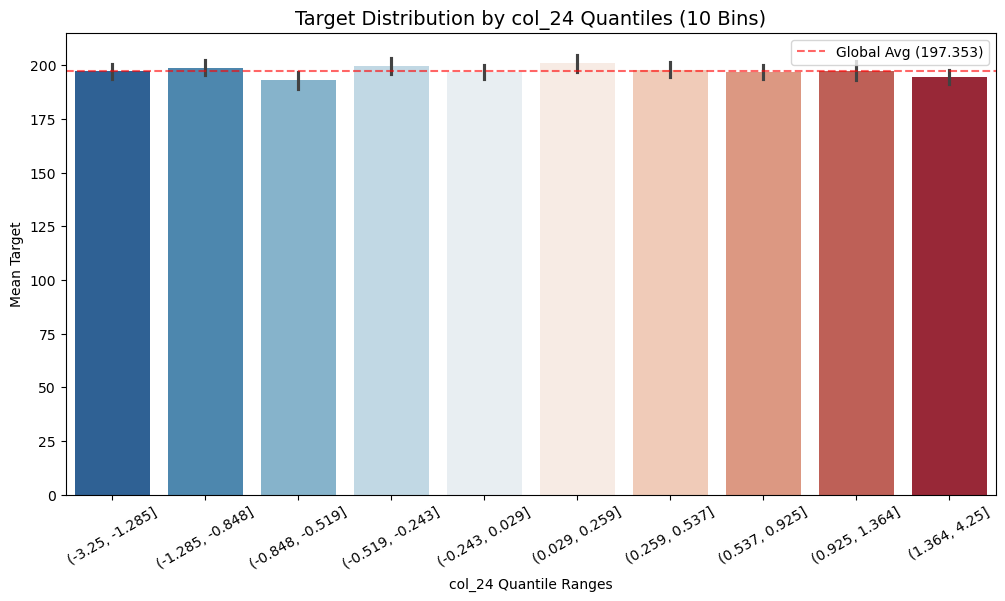

In [41]:
feature_analysis("col_24", 10)

In [51]:
clusters = {
    "Series A": ["col_1", "col_19", "col_23"],
    "Series B": ["col_2", "col_9", "col_18", "col_21"],
    "Cluster 3": ["col_3", "col_10", "col_20"],
    "Cluster 4": ["col_5", "col_11", "col_17", "col_22"],
    "Cluster 5": ["col_7", "col_13", "col_14", "col_15", "col_16"],
    "Cluster 6": ["col_8", "col_12"],
    "Cluster 7": ["col_6", "col_24"]
}

def evaluate_cluster_features(df, cluster_name, features, target='target'):
    results = []
    
    for feat in features:
        corr = df[feat].corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': feat, 'Type': 'Raw', 'Correlation': corr})
        
    combined_sum = df[features].sum(axis=1)
    corr_sum = combined_sum.corr(df[target])
    results.append({'Cluster': cluster_name, 'Feature': f"Sum({len(features)} feats)", 'Type': 'Combination (a+b)', 'Correlation': corr_sum})
    
    for a, b in combinations(features, 2):
        diff_feat = df[a] - df[b]
        corr_diff = diff_feat.corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': f"{a} - {b}", 'Type': 'Difference', 'Correlation': corr_diff})
        
    for a, b in combinations(features, 2):
        inter_feat = df[a] * df[b]
        corr_inter = inter_feat.corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': f"{a} * {b}", 'Type': 'Interaction', 'Correlation': corr_inter})
        
    return pd.DataFrame(results)

all_results = []
for name, cols in clusters.items():
    all_results.append(evaluate_cluster_features(df, name, cols))

summary_df = pd.concat(all_results)
summary_df['Abs_Corr'] = summary_df['Correlation'].abs()
summary_df = summary_df.sort_values(by=['Cluster', 'Abs_Corr'], ascending=[True, False])

best_per_cluster = summary_df.groupby('Cluster').head(1)
print("--- Best Performing Feature Transformation per Cluster ---")
display(best_per_cluster[['Cluster', 'Feature', 'Type', 'Correlation']])

display(summary_df)

--- Best Performing Feature Transformation per Cluster ---
              Cluster          Feature         Type  Correlation
0           Cluster 3            col_3          Raw    -0.035802
2           Cluster 4           col_17          Raw    -0.081342
25  Cluster 5 (Large)  col_15 * col_16  Interaction    -0.044021
3           Cluster 6   col_8 - col_12   Difference     0.030169
0           Cluster 7            col_6          Raw    -0.016204
0      Series A (Odd)            col_1          Raw     0.043973
0     Series B (Even)            col_2          Raw     0.131074


,Cluster,Feature,Type,Correlation,Abs_Corr
0,Cluster 3,col_3,Raw,-0.035802,0.035802
3,Cluster 3,Sum(3 feats),Combination (a+b),-0.031538,0.031538
1,Cluster 3,col_10,Raw,-0.030306,0.030306
2,Cluster 3,col_20,Raw,-0.026423,0.026423
5,Cluster 3,col_3 - col_20,Difference,-0.022075,0.022075
...,...,...,...,...,...
10,Series B (Even),col_18 - col_21,Difference,-0.012360,0.012360
6,Series B (Even),col_2 - col_18,Difference,0.009887,0.009887
7,Series B (Even),col_2 - col_21,Difference,-0.007401,0.007401
14,Series B (Even),col_9 * col_18,Interaction,0.006703,0.006703


In [141]:
df_final = df.copy()

df_final = df_final.drop(columns=['col_9', 'col_18', 'col_21'])

df_final = df_final.drop(columns=['col_19', 'col_23'])

df_final = df_final.drop(columns=['col_10', 'col_20'])

df_final = df_final.drop(columns=['col_5', 'col_11', 'col_22'])

df_final = df_final.drop(columns=['col_24'])

df_final = df_final.drop(columns=[col for col in df_final.columns if col.endswith('_cut')])

df_final['feat_15_16_interaction'] = df['col_15'] * df['col_16']
df_final = df_final.drop(columns=['col_7', 'col_13', 'col_14', 'col_15', 'col_16'])

df_final['feat_8_12_diff'] = df['col_8'] - df['col_12']
df_final = df_final.drop(columns=['col_8', 'col_12'])

print(f"Original feature count: {len(df.columns)}")
print(f"Refined feature count: {len(df_final.columns)}")

print(df_final.columns.tolist())

Original feature count: 26
Refined feature count: 10
['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_6', 'col_17', 'target', 'feat_15_16_interaction', 'feat_8_12_diff']


In [142]:
test_df = pd.read_csv("stock_8_test.csv")
test_df = test_df.drop(columns=['col_9', 'col_18', 'col_21'])

test_df = test_df.drop(columns=['col_19', 'col_23'])

test_df = test_df.drop(columns=['col_10', 'col_20'])

test_df = test_df.drop(columns=['col_5', 'col_11', 'col_22'])

test_df = test_df.drop(columns=['col_24'])

test_df = test_df.drop(columns=[col for col in df_final.columns if col.endswith('_cut')])


test_df['feat_15_16_interaction'] = test_df['col_15'] * df['col_16']
test_df = test_df.drop(columns=['col_7', 'col_13', 'col_14', 'col_15', 'col_16'])

test_df['feat_8_12_diff'] = test_df['col_8'] - test_df['col_12']
test_df = test_df.drop(columns=['col_8', 'col_12'])

print(test_df.columns.tolist())

['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_6', 'col_17', 'feat_15_16_interaction', 'feat_8_12_diff']


In [143]:
df_final['target'] = df['target']

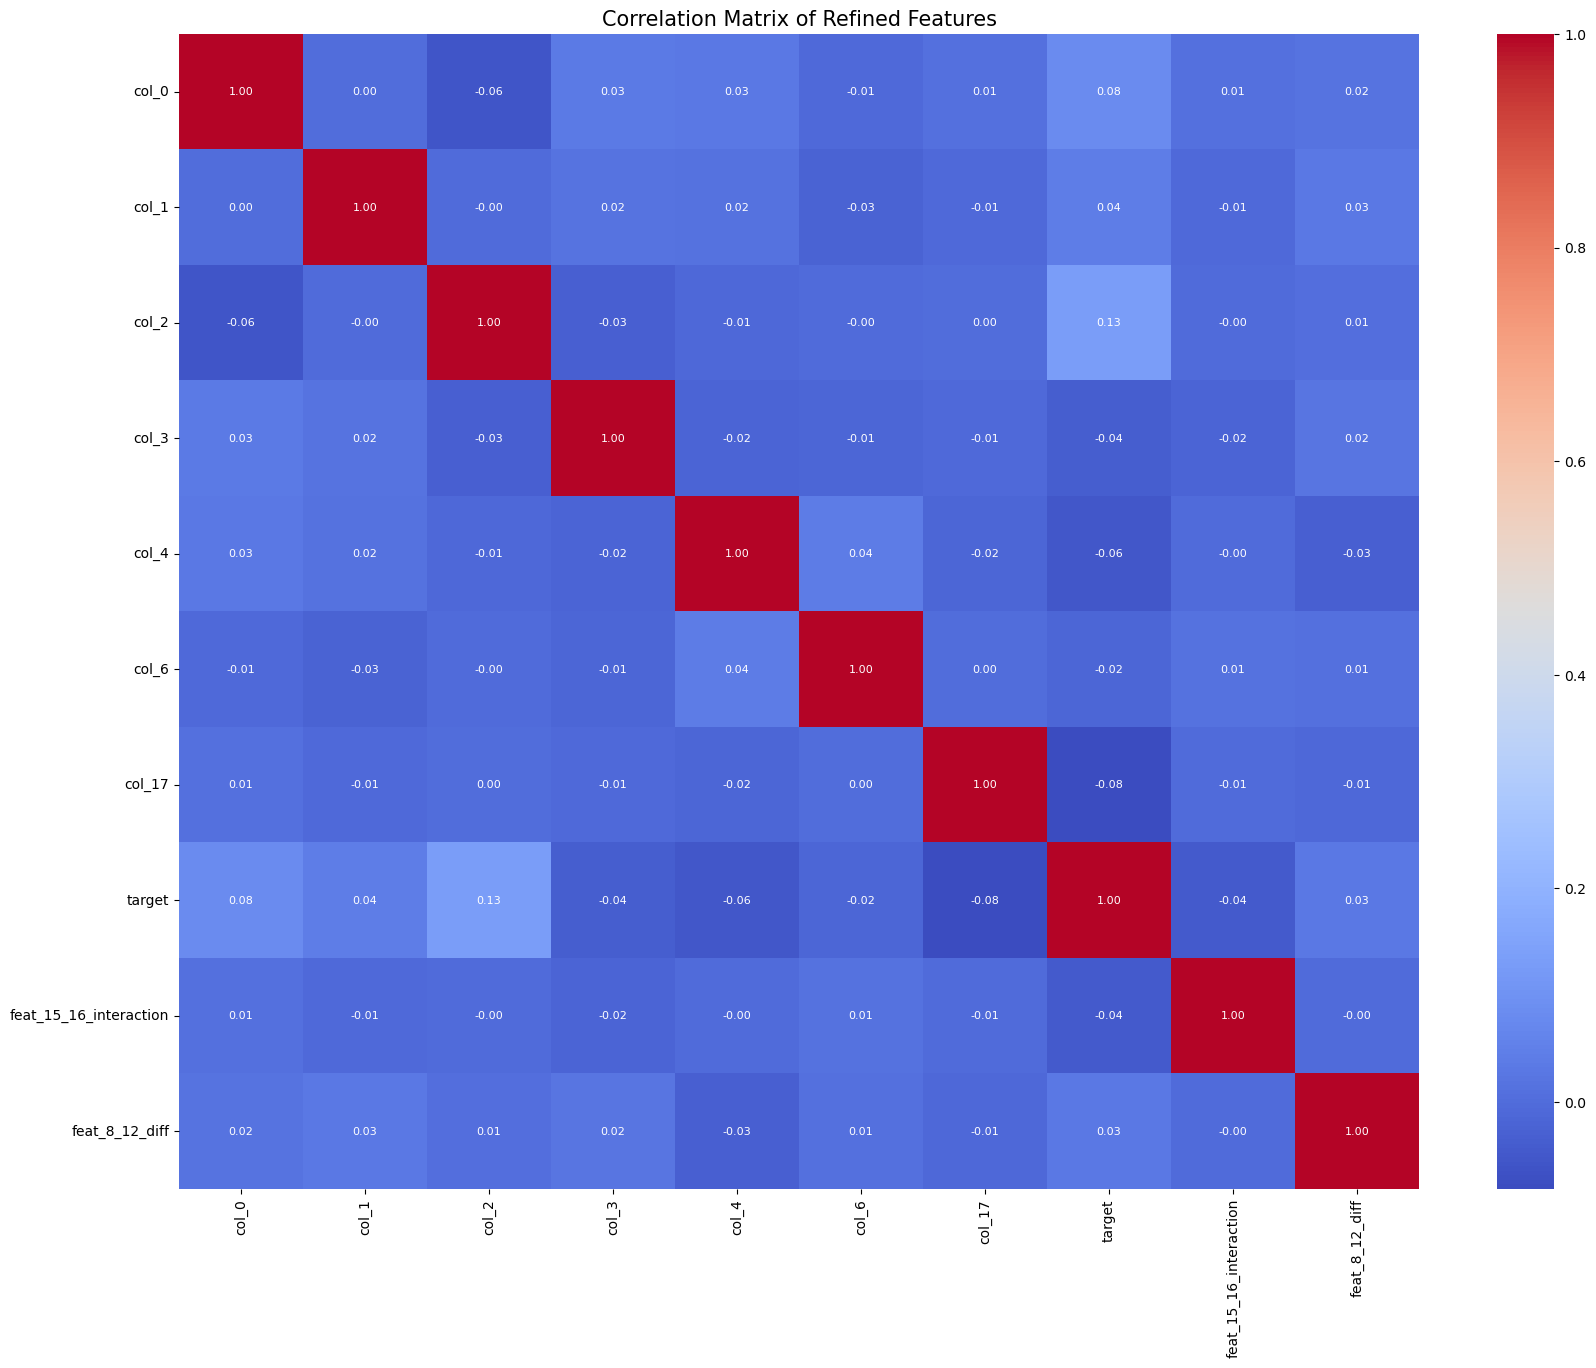

In [144]:
plt.figure(figsize=(20, 15))


corr_matrix = df_final.corr(numeric_only=True)

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            annot_kws={"size": 8})

plt.title("Correlation Matrix of Refined Features", fontsize=15)
plt.show()

In [147]:
y = df_final['target']
X_raw = df_final.drop(columns=['target'])


base_learners = [
    ('rf', RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)),
    ('gbm', HistGradientBoostingRegressor(max_iter=100, random_state=42)),
    ('svr', make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.1))),
    ('elastic', make_pipeline(StandardScaler(), ElasticNetCV(cv=5, random_state=42))),
    ('ridge_base', make_pipeline(StandardScaler(), RidgeCV()))
]

stacking_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=RidgeCV(),
    cv=5, 
    n_jobs=-1
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_rmse = []

print("Starting Cross-Validation with New Features...")
for train_index, val_index in tqdm(kf.split(X_raw), total=kf.get_n_splits(), desc="K-Fold Progress"):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    stacking_model.fit(X_train, y_train)
    preds = stacking_model.predict(X_val)
    fold_rmse.append(np.sqrt(mean_squared_error(y_val, preds)))

print(f"\nAverage RMSE:    {np.mean(fold_rmse):.4f}")
print(f"Std Dev of RMSE: {np.std(fold_rmse):.4f}")

print("\nPredicting on Test Data...")
stacking_model.fit(X_raw, y) # Final fit on all trained features

final_pred = stacking_model.predict(test_df)

print(f"Final Prediction: {final_pred[0]:.4f}")

Starting Cross-Validation with New Features...


K-Fold Progress: 100%|███████████████████████████████████████████████████████████████████| 5/5 [01:07<00:00, 13.41s/it]



Average RMSE:    25.9911
Std Dev of RMSE: 1.1314

Predicting on Test Data...
Final Prediction: 200.3015
